# TabKANet vs TabMLPNet — воспроизводимый эксперимент

Сравниваем две модели с одинаковой Transformer-частью:

**TabKANet**
`числовой признак → feature-wise KAN → token → Transformer → head`

**TabMLPNet**
`числовой признак → feature-wise MLP → token → Transformer → head`

Датасеты:
- Feynman Physics
- MAGIC Gamma Telescope
- Airfoil Self-Noise
- Breast Cancer Wisconsin
- CDC Diabetes Health Indicators
- Statlog Shuttle
- Combined Cycle Power Plant
- Concrete Compressive Strength
- Abalone

Главная цель ноутбука — не только получить метрики, но и сделать корректную визуальную проверку:

- **Feynman:** `EXACT analytical formula` vs `KAN prediction` vs `MLP prediction`;
- **реальные данные:** модельные feature-response curves + эмпирическая зависимость на test set.

> Важно: на реальных датасетах нет известной точной формулы, поэтому эмпирическая кривая не называется physical ground truth.

In [1]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

In [2]:
from sklearn.datasets import load_breast_cancer as sklearn_load_breast_cancer
from sklearn.datasets import fetch_openml

In [3]:
# ============================================================
# 0. Google Colab setup
# ============================================================
!pip -q install openpyxl xlrd

import io, os, gc, math, time, random, warnings, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import trange

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.5.1+cu121
Device: cuda


## 1. Конфигурация

Сначала запусти notebook с `RUN_MODE="quick"`. Он проверяет загрузку всех наборов и делает укороченный эксперимент.

Для итоговой версии защиты поставь:

```python
RUN_MODE = "full"
```

Тогда будет 5-fold cross-validation и более длительное обучение.

In [4]:
RUN_MODE = "quick"       # "quick" / "full"
SEED = 42

if RUN_MODE == "quick":
    N_FOLDS = 3
    EPOCHS = 60
    PATIENCE = 15
    MAX_ROWS = 30000
else:
    N_FOLDS = 5
    EPOCHS = 150
    PATIENCE = 25
    MAX_ROWS = None

# Feynman обучаем дольше: здесь проверяется совпадение с известной формулой.
FEYNMAN_EPOCHS = 180 if RUN_MODE == "quick" else 300
FEYNMAN_PATIENCE = 30 if RUN_MODE == "quick" else 45

BATCH_SIZE = 512
LR = 2e-3
WEIGHT_DECAY = 1e-5

RUN_DATASETS = [
    "feynman",
    "magic",
    "airfoil",
    "breast_cancer",
    "diabetes_cdc",
    "ccpp",
    "concrete",
    "abalone",
]

# None = автоматически выбрать простые вычислимые формулы.
FEYNMAN_IDS = None
N_FEYNMAN_EQUATIONS = 3
FEYNMAN_SAMPLES = 10000  # generate enough samples even if catalog row lists few datapoints

N_BINS = 25
N_CURVE_POINTS = 150

CACHE_DIR = Path("dataset_cache")
OUT_DIR = Path("tabkanet_tabmlpnet_results")
CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

## 2. Загрузка данных — сначала loaders, потом pre-flight

UCI-файлы скачиваются непосредственно из официального UCI repository и кэшируются локально.

Это принципиально важно: **никаких вызовов `load_dataset()` до определения функции**.

Каждый loader проверяет количество колонок и приводит данные к числовому виду.

In [5]:
UCI_URLS = {
    "magic": "https://archive.ics.uci.edu/static/public/159/magic+gamma+telescope.zip",
    "airfoil": "https://archive.ics.uci.edu/static/public/291/airfoil+self-noise.zip",
    "ccpp": "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip",
    "concrete": "https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip",
    "abalone": "https://archive.ics.uci.edu/static/public/1/abalone.zip",
    "shuttle": "https://archive.ics.uci.edu/static/public/148/statlog+shuttle.zip",
    "diabetes_cdc": "https://archive.ics.uci.edu/static/public/891/cdc+diabetes+health+indicators.zip",
}

def download_cached(url, filename):
    path = CACHE_DIR / filename
    if path.exists() and path.stat().st_size > 0:
        return path

    print("Downloading:", filename)
    request = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (Colab research)"}
    )
    with urllib.request.urlopen(request, timeout=120) as response:
        data = response.read()

    path.write_bytes(data)
    if path.stat().st_size < 100:
        raise RuntimeError(f"Downloaded file is too small: {path}")
    return path

def get_uci_zip(name):
    return download_cached(UCI_URLS[name], f"{name}.zip")

def zip_members(name):
    with zipfile.ZipFile(get_uci_zip(name)) as z:
        return z.namelist()

def find_member(names, suffixes=None, contains=None):
    result = []
    for name in names:
        low = name.lower()
        if suffixes is not None and not any(low.endswith(s.lower()) for s in suffixes):
            continue
        if contains is not None and not all(s.lower() in low for s in contains):
            continue
        result.append(name)

    if not result:
        raise FileNotFoundError(
            f"Archive member not found. contains={contains}, suffixes={suffixes}. "
            f"First members: {names[:30]}"
        )
    return result[0]

def read_member(name, member):
    with zipfile.ZipFile(get_uci_zip(name)) as z:
        return z.read(member)

def clean_xy(X, y):
    X = pd.DataFrame(X).copy()
    y = pd.Series(np.asarray(y).reshape(-1))

    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask].reset_index(drop=True).astype(float)
    y = y.loc[mask].reset_index(drop=True)

    if len(X) == 0:
        raise ValueError("No finite rows after cleaning.")
    if X.shape[1] == 0:
        raise ValueError("No features.")

    return X, y

def maybe_subsample(X, y, task, max_rows=None):
    """Ограничивает размер датасета, сохраняя стратификацию для классификации."""
    if max_rows is None or len(X) <= max_rows:
        return X, y

    rng = np.random.default_rng(SEED)

    if task == "classification":
        # Стратифицированная подвыборка
        y_arr = np.asarray(y)
        idx_keep = []
        for cls in np.unique(y_arr):
            cls_idx = np.where(y_arr == cls)[0]
            n_cls = max(1, int(round(max_rows * len(cls_idx) / len(y_arr))))
            n_cls = min(n_cls, len(cls_idx))
            idx_keep.extend(rng.choice(cls_idx, size=n_cls, replace=False))
        idx_keep = np.array(sorted(idx_keep))
    else:
        idx_keep = rng.choice(len(X), size=max_rows, replace=False)
        idx_keep = np.sort(idx_keep)

    X_sub = X.iloc[idx_keep].reset_index(drop=True)
    y_sub = pd.Series(np.asarray(y)[idx_keep]).reset_index(drop=True)
    return X_sub, y_sub

def load_magic():
    names = zip_members("magic")
    member = find_member(names, suffixes=[".data", ".csv"])
    df = pd.read_csv(io.BytesIO(read_member("magic", member)), header=None)

    if df.shape[1] != 11:
        raise ValueError(f"MAGIC: expected 11 columns, got {df.shape}")

    df.columns = [
        "fLength","fWidth","fSize","fConc","fConc1",
        "fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"
    ]
    X = df.iloc[:, :-1].astype(float)
    y = (df["class"].astype(str).str.strip().str.lower() == "g").astype(int)
    return X, y, "classification"

def load_airfoil():
    data = fetch_ucirepo(id=291)
    X = data.data.features
    y = data.data.targets
    return X.astype(float), y.iloc[:, 0].astype(float), "regression"

def load_ccpp():
    names = zip_members("ccpp")
    member = find_member(names, suffixes=[".xlsx", ".xls"])
    with zipfile.ZipFile(get_uci_zip("ccpp")) as z:
        raw = z.read(member)

    df = pd.read_excel(io.BytesIO(raw))
    if df.shape[1] < 5:
        raise ValueError(f"CCPP: expected at least 5 columns, got {df.shape}")

    df = df.iloc[:, :5].copy()
    df.columns = ["AT","V","AP","RH","PE"]
    return df.iloc[:, :-1].astype(float), df.iloc[:, -1].astype(float), "regression"

def load_concrete():
    names = zip_members("concrete")
    member = find_member(names, suffixes=[".xlsx", ".xls"])
    with zipfile.ZipFile(get_uci_zip("concrete")) as z:
        raw = z.read(member)

    df = pd.read_excel(io.BytesIO(raw))
    if df.shape[1] < 9:
        raise ValueError(f"Concrete: expected at least 9 columns, got {df.shape}")

    df = df.iloc[:, :9].copy()
    df.columns = [
        "cement","blast_furnace_slag","fly_ash","water",
        "superplasticizer","coarse_aggregate","fine_aggregate",
        "age","compressive_strength"
    ]
    return df.iloc[:, :-1].astype(float), df.iloc[:, -1].astype(float), "regression"

def load_abalone():
    names = zip_members("abalone")
    member = find_member(names, suffixes=[".data"])
    df = pd.read_csv(io.BytesIO(read_member("abalone", member)), header=None)

    if df.shape[1] != 9:
        raise ValueError(f"Abalone: expected 9 columns, got {df.shape}")

    df.columns = [
        "Sex","Length","Diameter","Height","Whole_weight",
        "Shucked_weight","Viscera_weight","Shell_weight","Rings"
    ]
    X = pd.get_dummies(df.iloc[:, :-1], columns=["Sex"], dtype=float)
    y = df["Rings"].astype(float)
    return X.astype(float), y, "regression"

def load_shuttle():
    """Statlog Shuttle с UCI (shuttle.trn и shuttle.tst)."""
    trn_path = CACHE_DIR / "shuttle.trn"
    tst_path = CACHE_DIR / "shuttle.tst"

    sources = {
        trn_path: "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/shuttle/shuttle.trn",
        tst_path: "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/shuttle/shuttle.tst",
    }

    for path, url in sources.items():
        if not path.exists() or path.stat().st_size < 100:
            print(f"Downloading {path.name}...")
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=120) as r:
                path.write_bytes(r.read())

    tr = pd.read_csv(trn_path, sep=r"\s+", header=None)
    te = pd.read_csv(tst_path, sep=r"\s+", header=None)
    df = pd.concat([tr, te], ignore_index=True)

    X = df.iloc[:, :7].apply(pd.to_numeric, errors="coerce").astype(float)
    y = df.iloc[:, 7].apply(pd.to_numeric, errors="coerce").astype(int) - 1

    mask = X.notna().all(axis=1) & y.notna()
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True), "classification"

def load_diabetes_cdc():
    data = fetch_ucirepo(id=891)
    X = data.data.features.apply(pd.to_numeric, errors="coerce")
    y = data.data.targets.iloc[:, 0]
    target_name = data.data.targets.columns[0]
    X, y = clean_xy(X, y)
    return X, y.astype(int), "classification"

def load_breast_cancer():
    """Загружает Breast Cancer Wisconsin через sklearn (совместимо со старыми версиями)."""
    try:
        data = sklearn_load_breast_cancer(as_frame=True)
        X = data.data.astype(float)
        y = pd.Series(data.target, name="target").astype(int)
    except TypeError:
        # Старый sklearn без as_frame
        data = sklearn_load_breast_cancer()
        feature_names = [f"f{i}" for i in range(data.data.shape[1])]
        X = pd.DataFrame(data.data, columns=feature_names).astype(float)
        y = pd.Series(data.target, name="target").astype(int)
    return X, y, "classification"

LOADERS = {
    "magic": load_magic,
    "airfoil": load_airfoil,
    "breast_cancer": load_breast_cancer,
    "diabetes_cdc": load_diabetes_cdc,
    "shuttle": load_shuttle,
    "ccpp": load_ccpp,
    "concrete": load_concrete,
    "abalone": load_abalone,
}

def validate_dataset(X, y, task, name):
    X = pd.DataFrame(X)
    y = pd.Series(y)

    if len(X) != len(y):
        raise ValueError(f"{name}: X/y length mismatch: {len(X)} vs {len(y)}")
    if X.shape[1] < 1:
        raise ValueError(f"{name}: no features")
    if not np.isfinite(X.to_numpy(dtype=float)).all():
        raise ValueError(f"{name}: non-finite feature values remain")
    if not np.isfinite(pd.to_numeric(y).to_numpy(dtype=float)).all():
        raise ValueError(f"{name}: non-finite target values remain")

    # Remove constant columns; they cannot carry a useful feature response.
    nunique = X.nunique(dropna=False)
    keep = nunique > 1
    if (~keep).any():
        X = X.loc[:, keep]

    if task == "classification" and y.nunique() < 2:
        raise ValueError(f"{name}: classification target has <2 classes")

    return X.reset_index(drop=True), y.reset_index(drop=True)

def load_dataset(name):
    if name == "feynman":
        raise ValueError("Feynman uses the separate formula loader.")

    X, y, task = LOADERS[name]()
    X, y = validate_dataset(X, y, task, name)
    return X, y, task

## 3. Pre-flight: сначала проверяем все 8 реальных датасетов

Эта ячейка **не обучает модели**.

Она должна вывести `OK` для каждого набора. Если здесь есть `FAIL`, обучение ниже запускать не надо — сначала исправляется конкретный loader.

In [6]:
preflight = []

for name in [x for x in RUN_DATASETS if x != "feynman"]:
    try:
        X, y, task = load_dataset(name)
        preflight.append({
            "dataset": name,
            "status": "OK",
            "rows": len(X),
            "features": X.shape[1],
            "task": task,
            "classes": int(y.nunique()) if task == "classification" else "-"
        })
        print(f"OK   {name:16s} X={X.shape} task={task}")
    except Exception as e:
        preflight.append({
            "dataset": name,
            "status": "FAIL",
            "rows": "-",
            "features": "-",
            "task": "-",
            "classes": "-"
        })
        print(f"FAIL {name:16s} -> {type(e).__name__}: {e}")

preflight_df = pd.DataFrame(preflight)
display(preflight_df)

failed = preflight_df.loc[preflight_df["status"] == "FAIL", "dataset"].tolist()
if failed:
    print("\nSTOP: исправь loaders для:", failed)
else:
    print("\nAll real-data loaders passed.")

OK   magic            X=(19020, 10) task=classification
OK   airfoil          X=(1503, 5) task=regression
OK   breast_cancer    X=(569, 30) task=classification
OK   diabetes_cdc     X=(253680, 21) task=classification
OK   ccpp             X=(9568, 4) task=regression
OK   concrete         X=(1030, 8) task=regression
OK   abalone          X=(4177, 10) task=regression


,dataset,status,rows,features,task,classes
0,magic,OK,19020,10,classification,2
1,airfoil,OK,1503,5,regression,-
2,breast_cancer,OK,569,30,classification,2
3,diabetes_cdc,OK,253680,21,classification,2
4,ccpp,OK,9568,4,regression,-
5,concrete,OK,1030,8,regression,-
6,abalone,OK,4177,10,regression,-



All real-data loaders passed.


## 4. KAN encoder и MLP encoder

Для каждого numerical feature строится отдельный encoder, который выдаёт token размерности `d_model=64`.

У KAN spline grid расширен до `[-3, 3]`. Это важно после `StandardScaler`: стандартное отклонение ≈ 1, поэтому диапазон `[-3,3]` не обрезает обычные значения так агрессивно, как `[-1,1]`.

In [7]:
class KANLinear(nn.Module):
    def __init__(
        self, in_features, out_features,
        grid_size=8, spline_order=3,
        scale_noise=0.05, scale_base=1.0, scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=nn.SiLU,
        grid_range=(-3.0, 3.0)
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            torch.arange(
                -spline_order,
                grid_size + spline_order + 1,
                dtype=torch.float32
            ) * h + grid_range[0]
        ).expand(in_features, -1).contiguous()

        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(
                out_features,
                in_features,
                grid_size + spline_order
            )
        )

        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(torch.empty(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)

        with torch.no_grad():
            noise = (
                (torch.rand(
                    self.grid_size + 1,
                    self.in_features,
                    self.out_features
                ) - 0.5)
                * self.scale_noise / self.grid_size
            )

            self.spline_weight.copy_(
                self.curve2coeff(
                    self.grid.T[self.spline_order:-self.spline_order],
                    noise
                )
            )

            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(
                    self.spline_scaler,
                    a=math.sqrt(5) * self.scale_spline
                )

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)

        bases = (
            (x >= grid[:, :-1]) &
            (x < grid[:, 1:])
        ).to(x.dtype)

        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, :-(k + 1)])
                / (grid[:, k:-1] - grid[:, :-(k + 1)])
            ) * bases[:, :, :-1] + (
                (grid[:, k + 1:] - x)
                / (grid[:, k + 1:] - grid[:, 1:(-k)])
            ) * bases[:, :, 1:]

        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        if self.enable_standalone_scale_spline:
            return self.spline_weight * self.spline_scaler.unsqueeze(-1)
        return self.spline_weight

    def forward(self, x):
        base = F.linear(self.base_activation(x), self.base_weight)

        spline = F.linear(
            self.b_splines(x).reshape(x.size(0), -1),
            self.scaled_spline_weight.reshape(self.out_features, -1)
        )

        return base + spline


class KAN(nn.Module):
    def __init__(self, layers_hidden, grid_size=8, spline_order=3):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLinear(
                a, b,
                grid_size=grid_size,
                spline_order=spline_order
            )
            for a, b in zip(layers_hidden, layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class FeatureWiseKANEncoder(nn.Module):
    def __init__(self, n_features, d_model=64, hidden_dim=4):
        super().__init__()
        self.models = nn.ModuleList([
            KAN([1, hidden_dim, d_model])
            for _ in range(n_features)
        ])

    def forward(self, x):
        tokens = [
            model(x[:, i:i+1]).unsqueeze(1)
            for i, model in enumerate(self.models)
        ]
        return torch.cat(tokens, dim=1)


class FeatureWiseMLPEncoder(nn.Module):
    def __init__(self, n_features, d_model=64, hidden_dim=16):
        super().__init__()
        self.models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, d_model),
            )
            for _ in range(n_features)
        ])

    def forward(self, x):
        tokens = [
            model(x[:, i:i+1]).unsqueeze(1)
            for i, model in enumerate(self.models)
        ]
        return torch.cat(tokens, dim=1)

## 5. Общая TabTransformer-часть

Единственное различие между моделями — numerical encoder.

Transformer, column embeddings и prediction head одинаковые.

In [8]:
class TabKANet(nn.Module):
    def __init__(
        self, n_features, output_dim,
        d_model=64, n_heads=8, n_layers=3,
        ff_dim=128, dropout=0.1
    ):
        super().__init__()

        self.encoder = FeatureWiseKANEncoder(
            n_features, d_model=d_model, hidden_dim=4
        )
        self.column_embedding = nn.Parameter(
            torch.randn(n_features, d_model) * 0.02
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, output_dim)
        )

    def forward(self, x):
        tokens = self.encoder(x) + self.column_embedding.unsqueeze(0)
        z = self.transformer(tokens).mean(dim=1)
        return self.head(z)


class TabMLPNet(nn.Module):
    def __init__(
        self, n_features, output_dim,
        d_model=64, n_heads=8, n_layers=3,
        ff_dim=128, dropout=0.1
    ):
        super().__init__()

        self.encoder = FeatureWiseMLPEncoder(
            n_features, d_model=d_model, hidden_dim=32
        )
        self.column_embedding = nn.Parameter(
            torch.randn(n_features, d_model) * 0.02
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, output_dim)
        )

    def forward(self, x):
        tokens = self.encoder(x) + self.column_embedding.unsqueeze(0)
        z = self.transformer(tokens).mean(dim=1)
        return self.head(z)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
# Parameter-count sanity check
_dummy_kan = TabKANet(8, 1).to(DEVICE)
_dummy_mlp = TabMLPNet(8, 1).to(DEVICE)

print("TabKANet parameters:", f"{count_params(_dummy_kan):,}")
print("TabMLPNet parameters:", f"{count_params(_dummy_mlp):,}")

del _dummy_kan, _dummy_mlp
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

TabKANet parameters: 132,321
TabMLPNet parameters: 131,137


## 6. Обучение

Для regression стандартизируем **X по train fold** и дополнительно стандартизируем `y` по train fold. После предсказания `y` возвращается в исходный масштаб.

Для classification используем CrossEntropyLoss и softmax probability для AUC/визуализации.

Early stopping использует validation set. Test set не используется для выбора эпохи.

In [10]:
def make_splits(X, y, task, n_folds, seed):
    if task == "classification":
        splitter = StratifiedKFold(
            n_splits=n_folds,
            shuffle=True,
            random_state=seed
        )
        return list(splitter.split(X, y))

    splitter = KFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=seed
    )
    return list(splitter.split(X))


def metric_from_outputs(y_true, outputs, task):
    outputs = np.asarray(outputs)

    if task == "regression":
        pred = outputs.reshape(-1)
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true, pred))),
            "r2": float(r2_score(y_true, pred))
        }

    probs = torch.softmax(
        torch.tensor(outputs, dtype=torch.float32),
        dim=1
    ).numpy()

    if len(np.unique(y_true)) == 2:
        return {
            "auc": float(roc_auc_score(y_true, probs[:, 1]))
        }

    pred = np.argmax(probs, axis=1)
    return {
        "macro_f1": float(
            f1_score(y_true, pred, average="macro")
        )
    }


def predict_outputs(model, X_scaled):
    loader = DataLoader(
        torch.tensor(X_scaled, dtype=torch.float32),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    out = []
    model.eval()

    with torch.no_grad():
        for xb in loader:
            out.append(
                model(xb.to(DEVICE)).cpu().numpy()
            )

    return np.concatenate(out, axis=0)


def train_single_fold(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    task, model_kind,
    epochs, patience,
    seed=42
):
    seed_everything(seed)

    x_scaler = StandardScaler()
    Xtr = x_scaler.fit_transform(X_train).astype(np.float32)
    Xv = x_scaler.transform(X_val).astype(np.float32)
    Xte = x_scaler.transform(X_test).astype(np.float32)

    if task == "regression":
        y_mean = float(np.mean(y_train))
        y_std = float(np.std(y_train))
        if y_std < 1e-8:
            y_std = 1.0

        ytr = ((np.asarray(y_train) - y_mean) / y_std).astype(np.float32)
        yv = ((np.asarray(y_val) - y_mean) / y_std).astype(np.float32)
        yte = ((np.asarray(y_test) - y_mean) / y_std).astype(np.float32)

        output_dim = 1
        y_scaler = (y_mean, y_std)

    else:
        ytr = np.asarray(y_train, dtype=np.int64)
        yv = np.asarray(y_val, dtype=np.int64)
        yte = np.asarray(y_test, dtype=np.int64)

        output_dim = int(max(ytr.max(), yv.max(), yte.max()) + 1)
        y_scaler = None

    Model = TabKANet if model_kind == "KAN" else TabMLPNet
    model = Model(
        Xtr.shape[1],
        output_dim
    ).to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(Xtr),
            torch.tensor(ytr)
        ),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(Xv),
            torch.tensor(yv)
        ),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    criterion = (
        nn.MSELoss()
        if task == "regression"
        else nn.CrossEntropyLoss()
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(3, patience // 3)
    )

    best_val = np.inf
    best_state = None
    bad_epochs = 0

    for epoch in trange(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)

            if task == "regression":
                loss = criterion(pred.reshape(-1), yb)
            else:
                loss = criterion(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                pred = model(xb)

                if task == "regression":
                    loss = criterion(pred.reshape(-1), yb)
                else:
                    loss = criterion(pred, yb)

                val_losses.append(float(loss.item()))

        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was saved.")

    model.load_state_dict(best_state)
    model.to(DEVICE)

    val_outputs = predict_outputs(model, Xv)
    test_outputs = predict_outputs(model, Xte)

    # Return predictions in original target scale for regression.
    if task == "regression":
        val_pred = val_outputs.reshape(-1) * y_scaler[1] + y_scaler[0]
        test_pred = test_outputs.reshape(-1) * y_scaler[1] + y_scaler[0]

        val_metric = metric_from_outputs(y_val, val_pred, task)
        test_metric = metric_from_outputs(y_test, test_pred, task)

    else:
        val_metric = metric_from_outputs(y_val, val_outputs, task)
        test_metric = metric_from_outputs(y_test, test_outputs, task)

    return {
        "model": model,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "val_metric": val_metric,
        "test_metric": test_metric,
        "val_outputs": val_outputs,
        "test_outputs": test_outputs,
        "epochs_used": epoch,
        "params": count_params(model)
    }

## 7. Feature-response curves для реальных данных

Для classification на графике используется **probability of class 1**, а не raw logit. Поэтому шкала модели сопоставима с эмпирической долей положительного класса.

Для multiclass показываем probability выбранного класса `1`.

Для regression показываем prediction в исходном масштабе target.

In [11]:
def model_curve(
    model, x_scaler, y_scaler,
    X_reference, feature_idx,
    task, n_points=150, class_id=1
):
    X_reference = np.asarray(X_reference, dtype=float)

    lo, hi = np.percentile(
        X_reference[:, feature_idx],
        [1, 99]
    )

    grid = np.linspace(lo, hi, n_points)

    base = np.median(
        X_reference,
        axis=0,
        keepdims=True
    )

    Xgrid = np.repeat(base, n_points, axis=0)
    Xgrid[:, feature_idx] = grid

    Xscaled = x_scaler.transform(Xgrid).astype(np.float32)
    outputs = predict_outputs(model, Xscaled)

    if task == "regression":
        pred = (
            outputs.reshape(-1) * y_scaler[1]
            + y_scaler[0]
        )
    else:
        probs = torch.softmax(
            torch.tensor(outputs, dtype=torch.float32),
            dim=1
        ).numpy()
        pred = probs[:, class_id]

    return grid, pred


def empirical_curve(
    X, y, feature_idx,
    task, n_bins=25, class_id=1
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    x = X[:, feature_idx]
    edges = np.unique(
        np.quantile(
            x,
            np.linspace(0, 1, n_bins + 1)
        )
    )

    if len(edges) < 5:
        return np.array([]), np.array([])

    bin_ids = np.digitize(
        x,
        edges[1:-1],
        right=True
    )

    xs, ys = [], []

    for b in range(len(edges) - 1):
        mask = bin_ids == b

        if mask.sum() < 10:
            continue

        xs.append(float(np.median(x[mask])))

        if task == "regression":
            ys.append(float(np.mean(y[mask])))
        else:
            ys.append(float(np.mean(y[mask] == class_id)))

    return np.asarray(xs), np.asarray(ys)


def plot_real_feature_curves(
    artifact,
    dataset_name,
    max_features=8
):
    X_test = artifact["X_test"]
    y_test = artifact["y_test"]
    task = artifact["task"]

    feature_names = artifact["feature_names"]
    n = min(len(feature_names), max_features)

    rows = int(np.ceil(n / 2))
    fig, axes = plt.subplots(
        rows, 2,
        figsize=(15, 4.2 * rows)
    )
    axes = np.asarray(axes).reshape(-1)

    for i in range(n):
        ax = axes[i]

        ex, ey = empirical_curve(
            X_test, y_test, i, task, N_BINS
        )

        if len(ex):
            ax.scatter(
                ex, ey,
                s=22,
                alpha=0.7,
                label="empirical test"
            )

        for kind in ["KAN", "MLP"]:
            gx, gy = model_curve(
                artifact["models"][kind],
                artifact["x_scalers"][kind],
                artifact["y_scalers"][kind],
                X_test,
                i,
                task,
                N_CURVE_POINTS
            )
            ax.plot(
                gx, gy,
                linewidth=2,
                label=kind
            )

        ax.set_title(feature_names[i])
        ax.set_xlabel("feature value")
        ax.set_ylabel(
            "prediction / P(class=1)"
            if task == "classification"
            else "target / prediction"
        )
        ax.grid(alpha=0.2)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    axes[0].legend()
    fig.suptitle(
        f"{dataset_name}: feature-response comparison",
        fontsize=15
    )
    fig.tight_layout()
    plt.show()

## 8. Запуск одного реального датасета

Используем одинаковые outer folds для KAN и MLP.

В каждом outer fold:
- train/validation/test;
- StandardScaler fit только на train;
- early stopping только по validation;
- итоговая метрика считается на test.

Сохраняем **лучший fold для каждого типа модели отдельно**, чтобы визуализация действительно содержала и KAN, и MLP.

In [12]:
def run_real_dataset(name):
    Xdf, y, task = load_dataset(name)
    Xdf, y = maybe_subsample(Xdf, y, task, MAX_ROWS)

    X = Xdf.to_numpy(dtype=float)
    y = np.asarray(y)

    splits = make_splits(
        X, y, task, N_FOLDS, SEED
    )

    result_rows = []

    # For visualization we deliberately keep BOTH models from the SAME fold.
    # This avoids applying an MLP trained on fold k to a KAN fold j test set.
    visualization_bundle = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        if task == "classification":
            tr_idx, val_idx = train_test_split(
                train_idx,
                test_size=0.15,
                stratify=y[train_idx],
                random_state=SEED + fold
            )
        else:
            tr_idx, val_idx = train_test_split(
                train_idx,
                test_size=0.15,
                random_state=SEED + fold
            )

        fold_models = {}

        for kind in ["KAN", "MLP"]:
            t0 = time.time()

            fit = train_single_fold(
                X[tr_idx], y[tr_idx],
                X[val_idx], y[val_idx],
                X[test_idx], y[test_idx],
                task,
                kind,
                EPOCHS,
                PATIENCE,
                seed=SEED + fold
            )

            elapsed = time.time() - t0

            result_rows.append({
                "dataset": name,
                "fold": fold,
                "model": kind,
                "task": task,
                "params": fit["params"],
                "epochs": fit["epochs_used"],
                "time_sec": elapsed,
                **fit["test_metric"]
            })

            fold_models[kind] = fit

            del fit
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Save fold 1 for visualization. Both models use exactly the same test set.
        if visualization_bundle is None:
            visualization_bundle = {
                "X_test": X[test_idx].copy(),
                "y_test": y[test_idx].copy(),
                "models": {
                    "KAN": fold_models["KAN"]["model"],
                    "MLP": fold_models["MLP"]["model"]
                },
                "x_scalers": {
                    "KAN": fold_models["KAN"]["x_scaler"],
                    "MLP": fold_models["MLP"]["x_scaler"]
                },
                "y_scalers": {
                    "KAN": fold_models["KAN"]["y_scaler"],
                    "MLP": fold_models["MLP"]["y_scaler"]
                }
            }

    result_df = pd.DataFrame(result_rows)

    artifact = {
        "task": task,
        "feature_names": list(Xdf.columns),
        "X_test": visualization_bundle["X_test"],
        "y_test": visualization_bundle["y_test"],
        "models": visualization_bundle["models"],
        "x_scalers": visualization_bundle["x_scalers"],
        "y_scalers": visualization_bundle["y_scalers"]
    }

    return result_df, artifact

## 9. Полный запуск реальных датасетов

После этой ячейки должны появиться:
- `real_results.csv`;
- таблица средних метрик KAN/MLP;
- feature-response графики для каждого успешно обученного набора.

Если один dataset упадёт, остальные продолжают выполняться, а ошибка записывается в `failed_datasets`.


DATASET: magic
Loaded: rows=19,020, features=10, task=classification


 75%|███████▌  | 45/60 [00:14<00:04,  3.07it/s]



CV results:


,fold,params,epochs,time_sec,auc
model,,,,,
KAN,2.0,139274.0,41.33333,32.80784,0.92910
MLP,2.0,137794.0,42.00000,13.68141,0.93082


Feature-response plots:


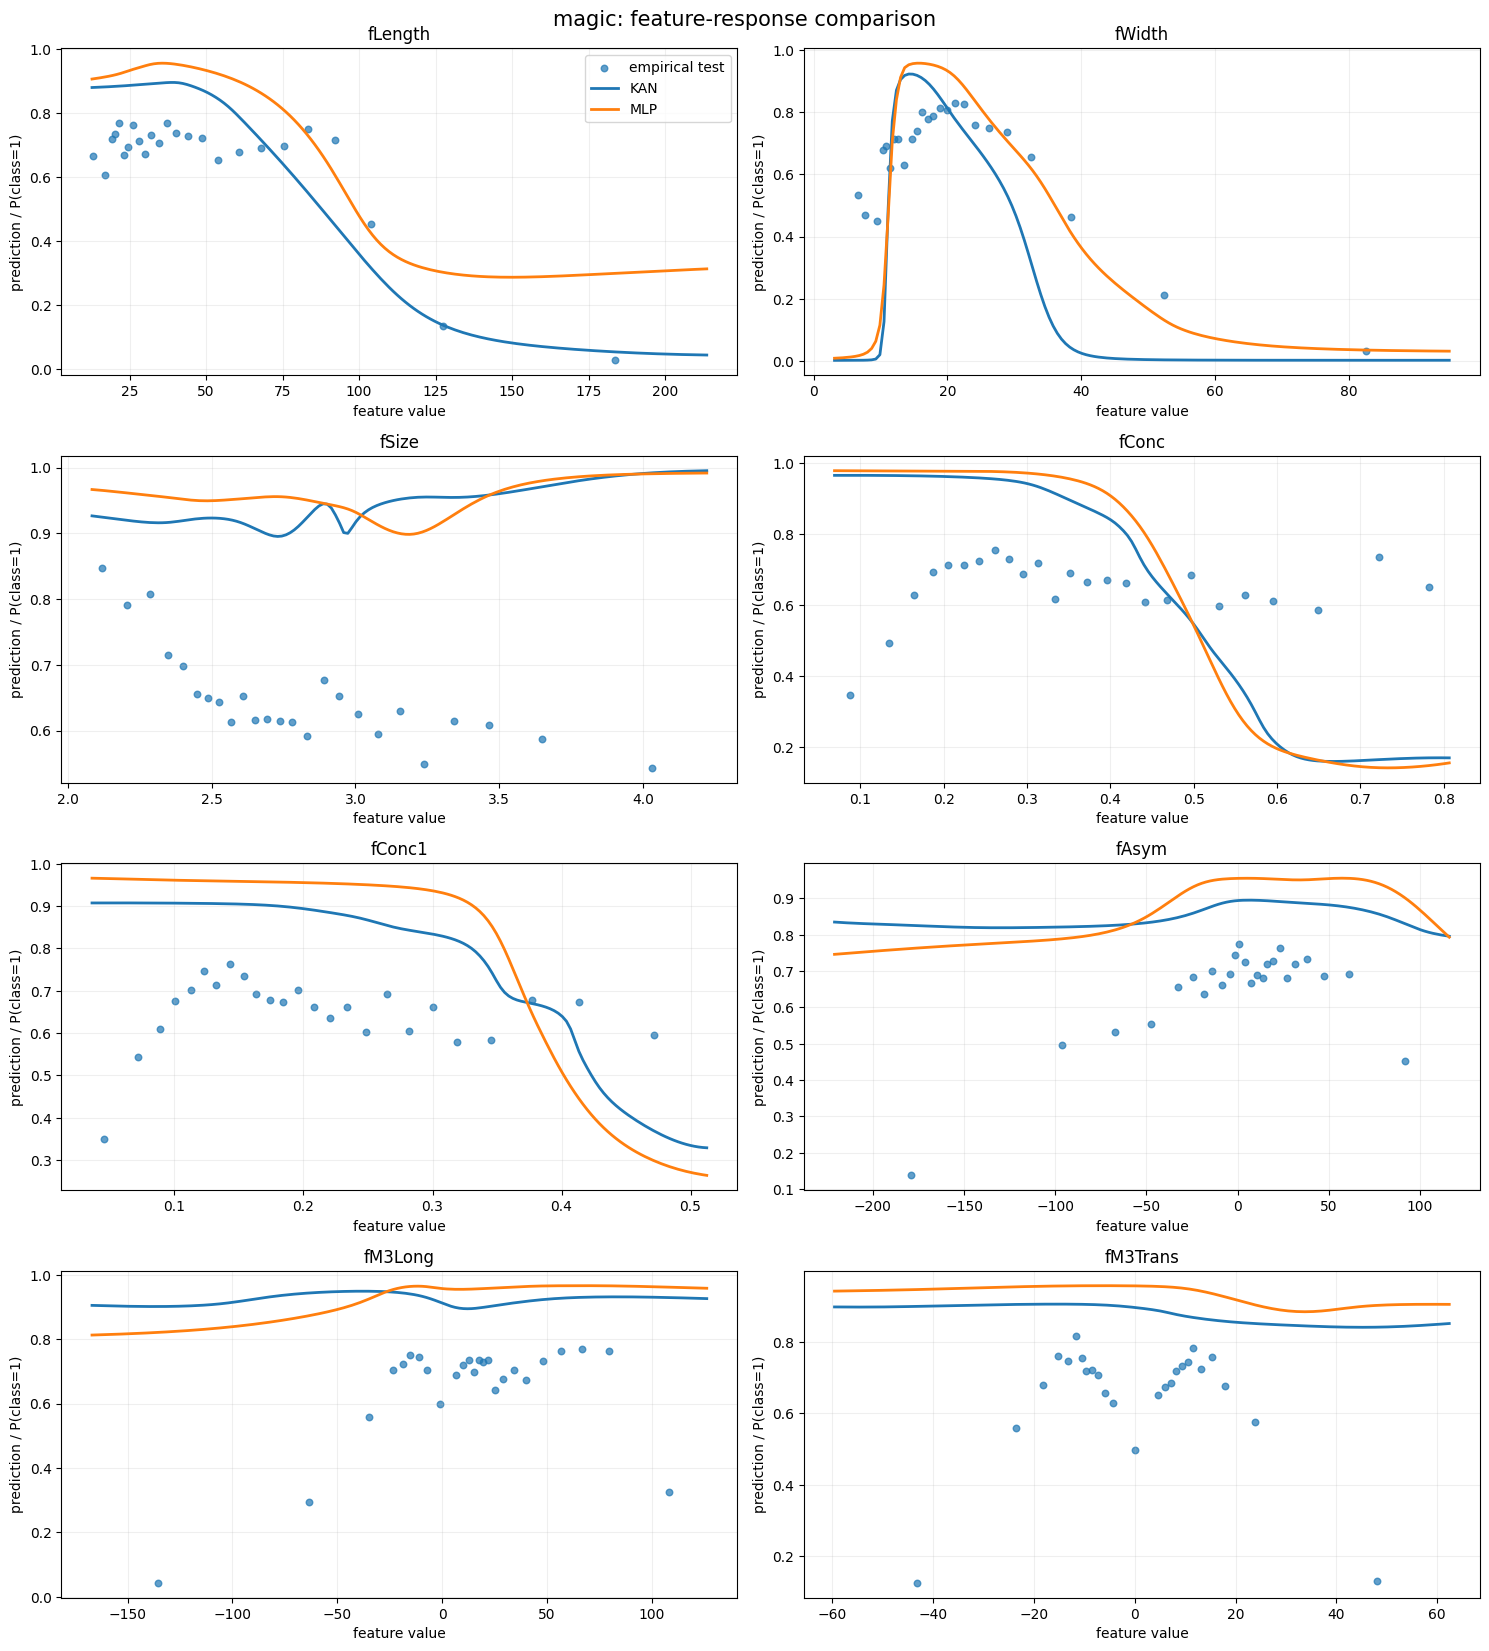


DATASET: airfoil
Loaded: rows=1,503, features=5, task=regression


100%|██████████| 60/60 [00:01<00:00, 36.33it/s]



CV results:


,fold,params,epochs,time_sec,rmse,r2
model,,,,,,
KAN,2.0,121989.0,60.0,3.67297,2.04635,0.91122
MLP,2.0,121249.0,60.0,1.70530,2.03366,0.91249


Feature-response plots:


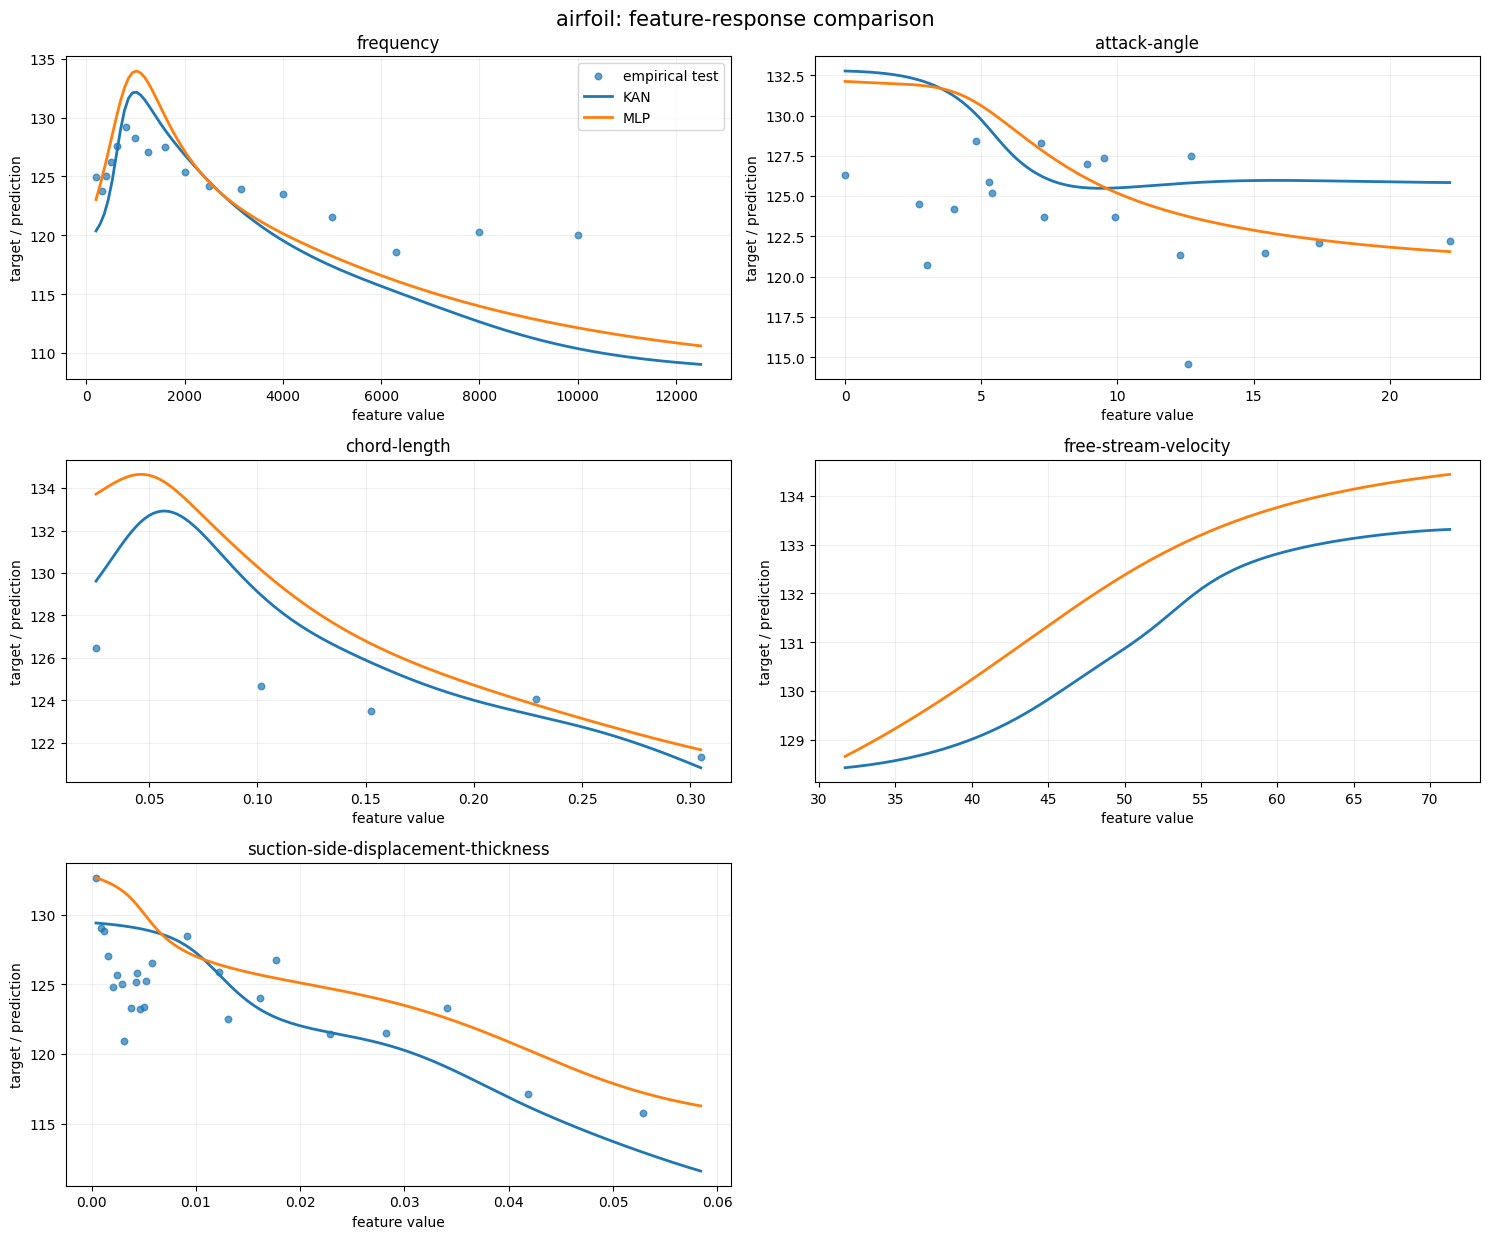


DATASET: breast_cancer
Loaded: rows=569, features=30, task=classification


 50%|█████     | 30/60 [00:00<00:00, 30.52it/s]



CV results:


,fold,params,epochs,time_sec,auc
model,,,,,
KAN,2.0,208154.0,36.33333,4.37087,0.99320
MLP,2.0,203714.0,33.66667,1.09233,0.99332


Feature-response plots:


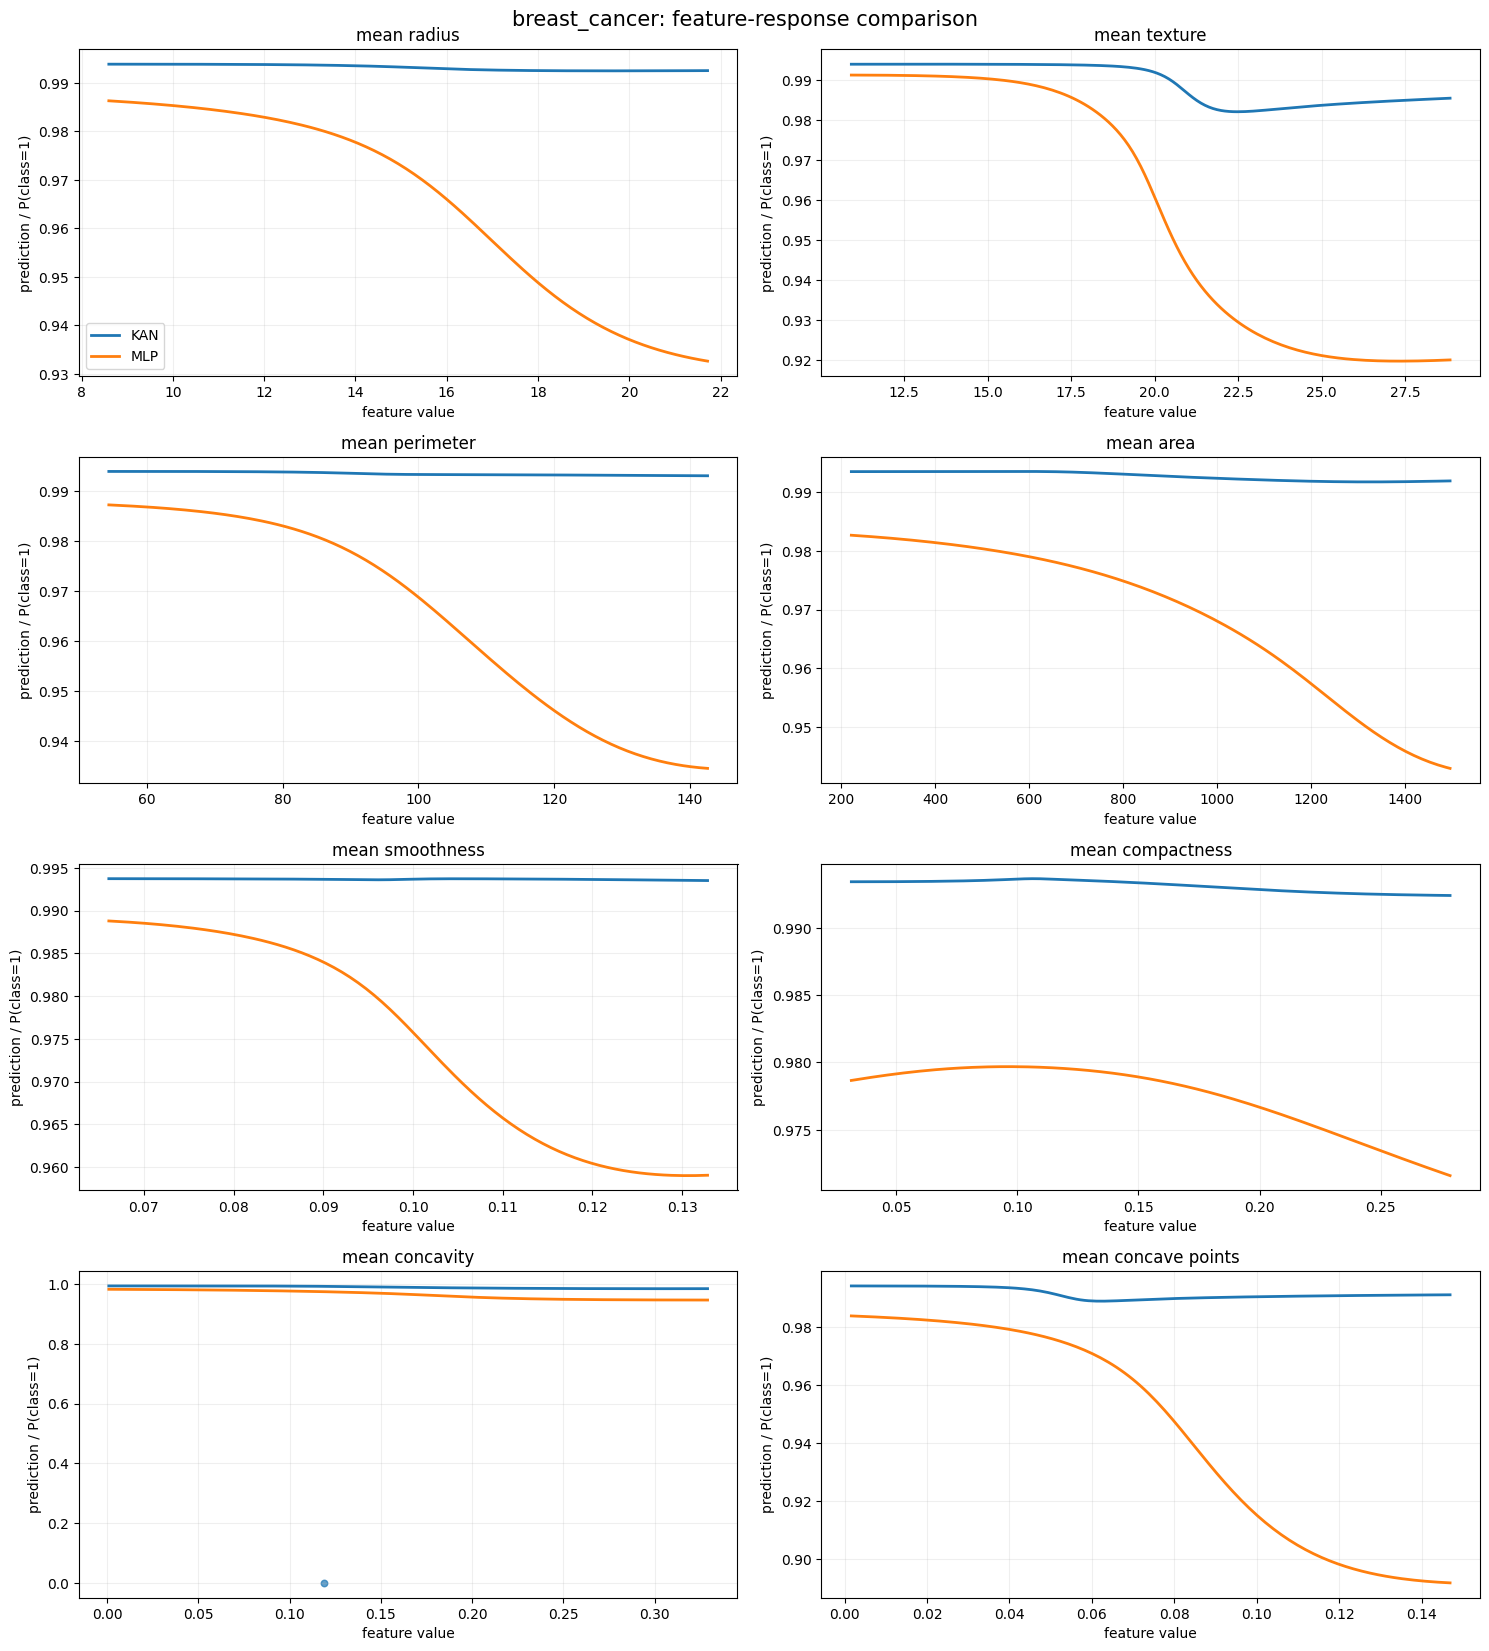


DATASET: diabetes_cdc
Loaded: rows=253,680, features=21, task=classification


 40%|████      | 24/60 [00:16<00:24,  1.44it/s]



CV results:


,fold,params,epochs,time_sec,auc
model,,,,,
KAN,2.0,177158.0,28.00000,59.78771,0.82310
MLP,2.0,174050.0,27.33333,18.74372,0.82411


Feature-response plots:


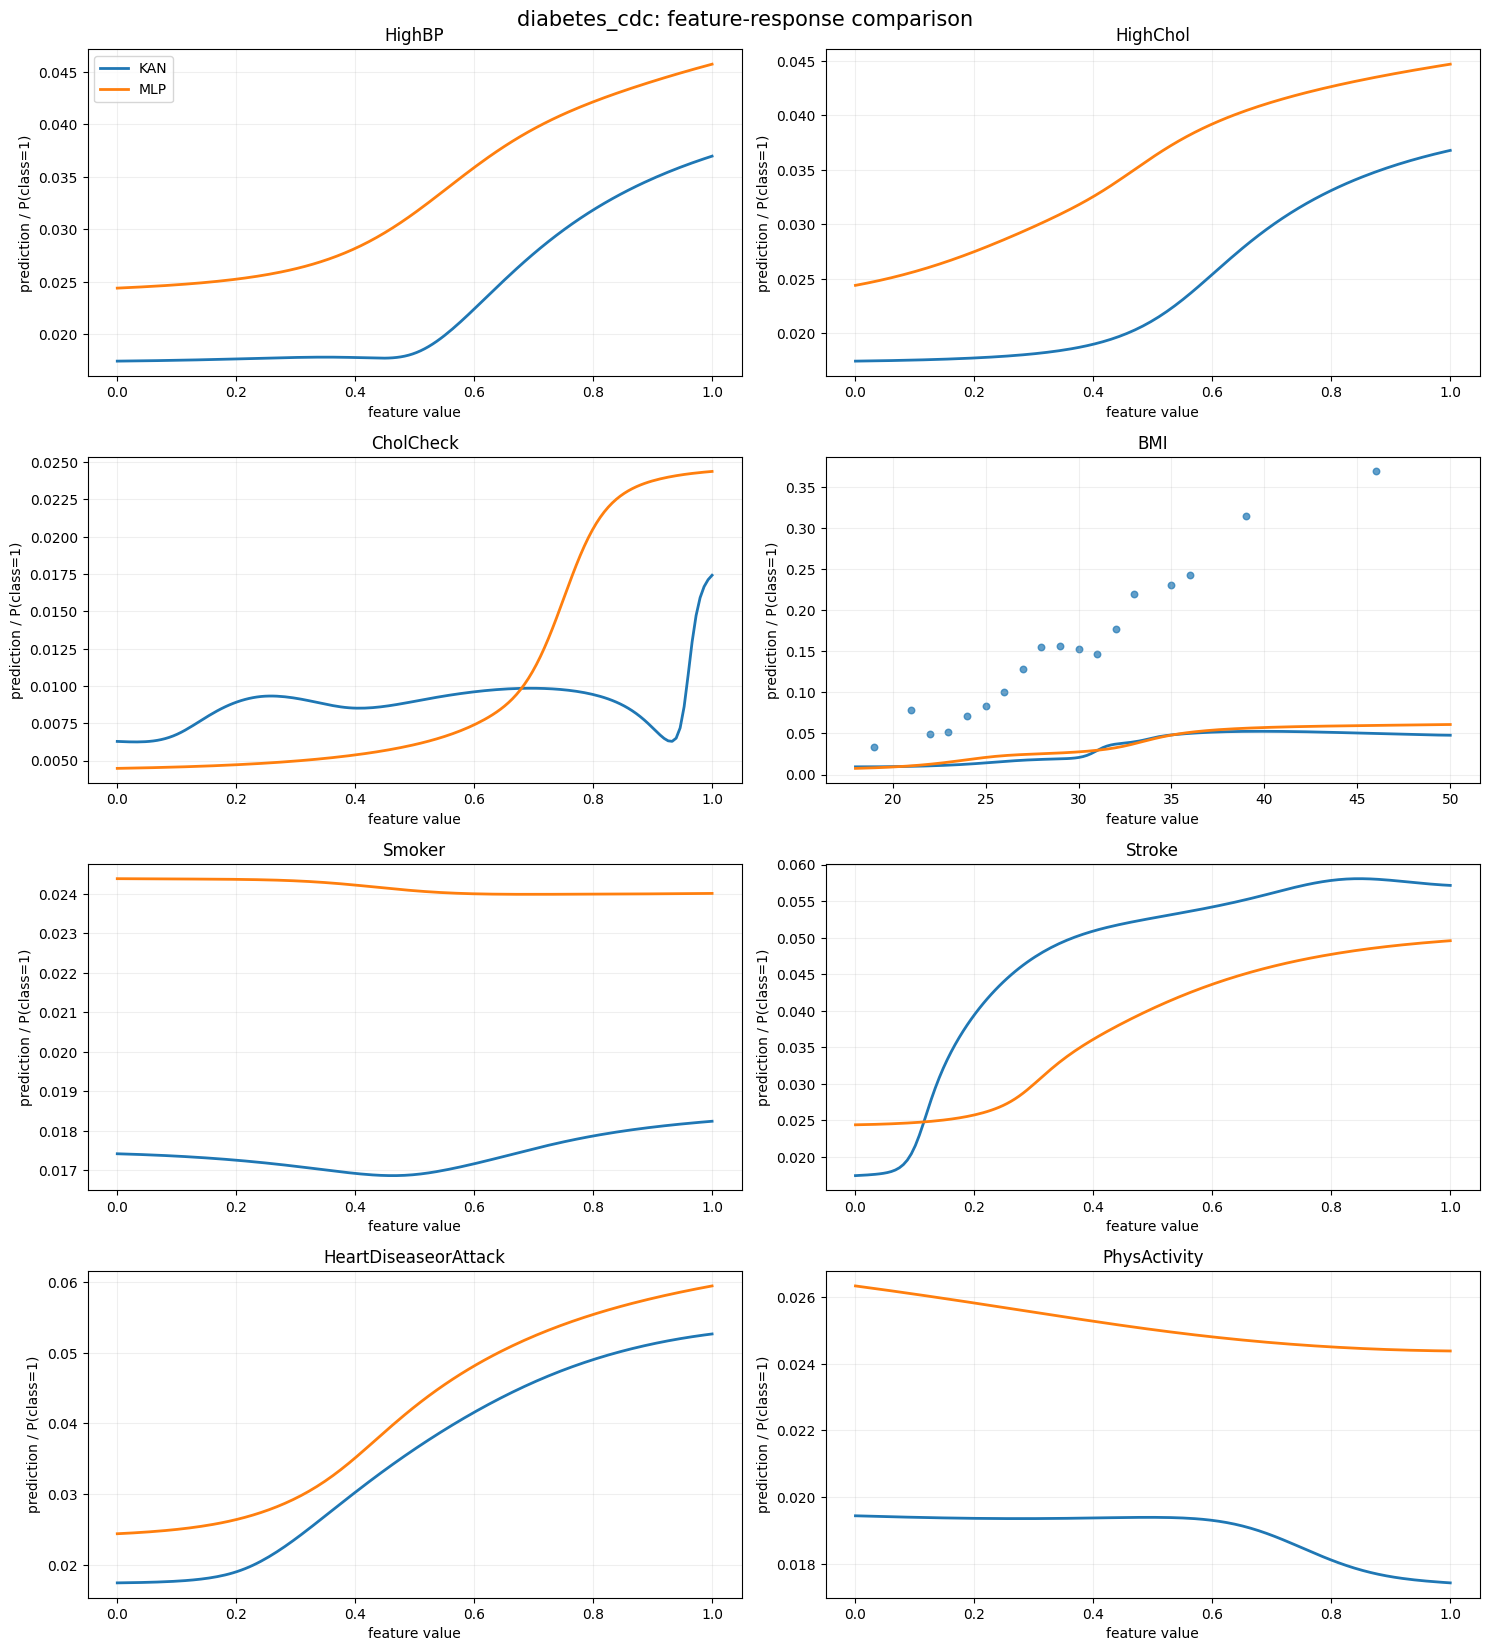


DATASET: ccpp
Loaded: rows=9,568, features=4, task=regression


100%|██████████| 60/60 [00:07<00:00,  7.57it/s]



CV results:


,fold,params,epochs,time_sec,rmse,r2
model,,,,,,
KAN,2.0,118545.0,53.33333,10.95627,4.01247,0.94471
MLP,2.0,117953.0,60.00000,7.96898,3.99058,0.94532


Feature-response plots:


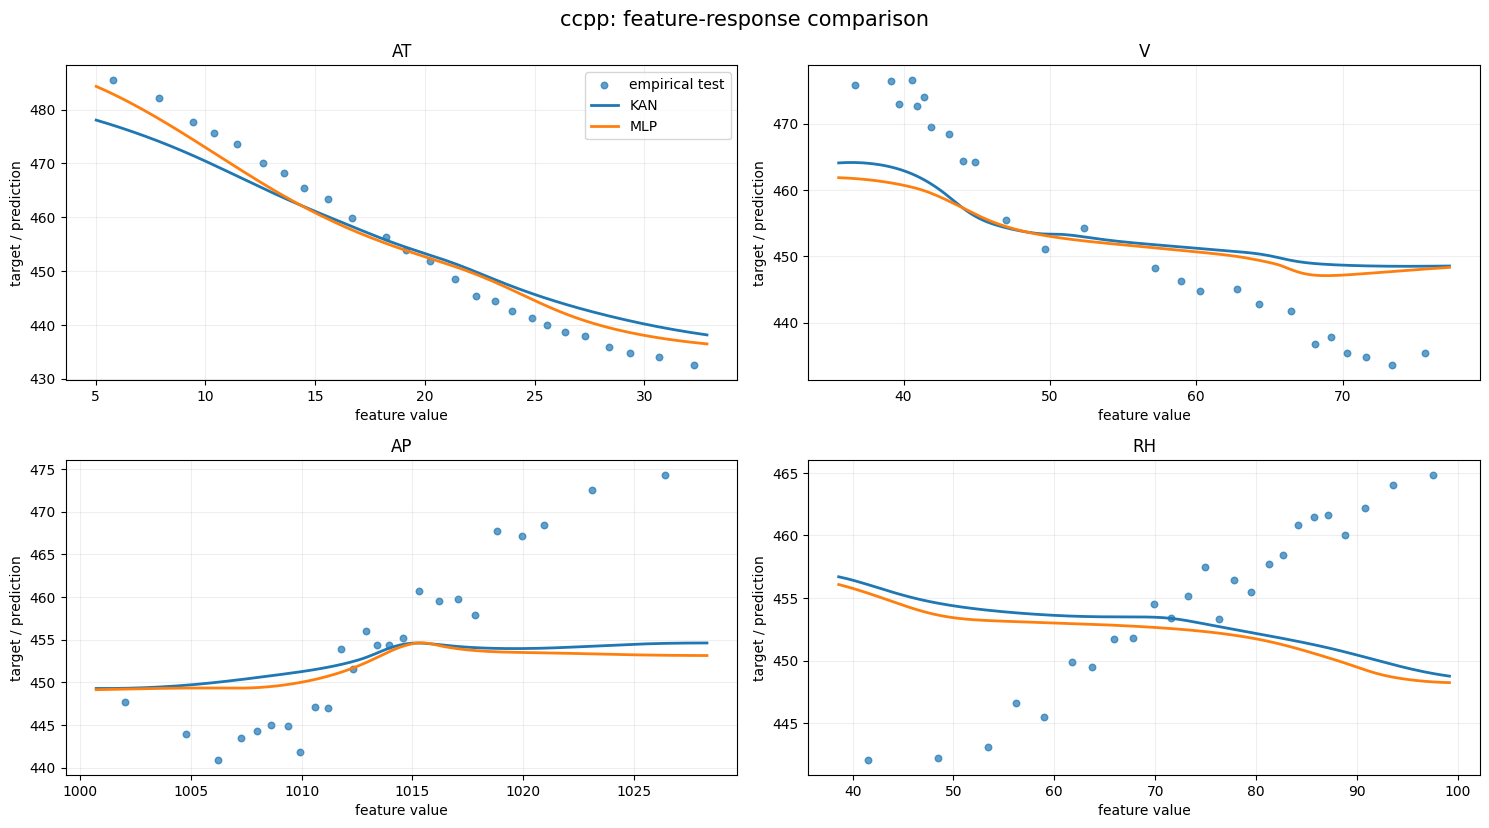


DATASET: concrete
Loaded: rows=1,030, features=8, task=regression


 87%|████████▋ | 52/60 [00:01<00:00, 35.86it/s]



CV results:


,fold,params,epochs,time_sec,rmse,r2
model,,,,,,
KAN,2.0,132321.0,60.00000,3.83256,5.92315,0.87374
MLP,2.0,131137.0,49.66667,1.39796,6.49403,0.84746


Feature-response plots:


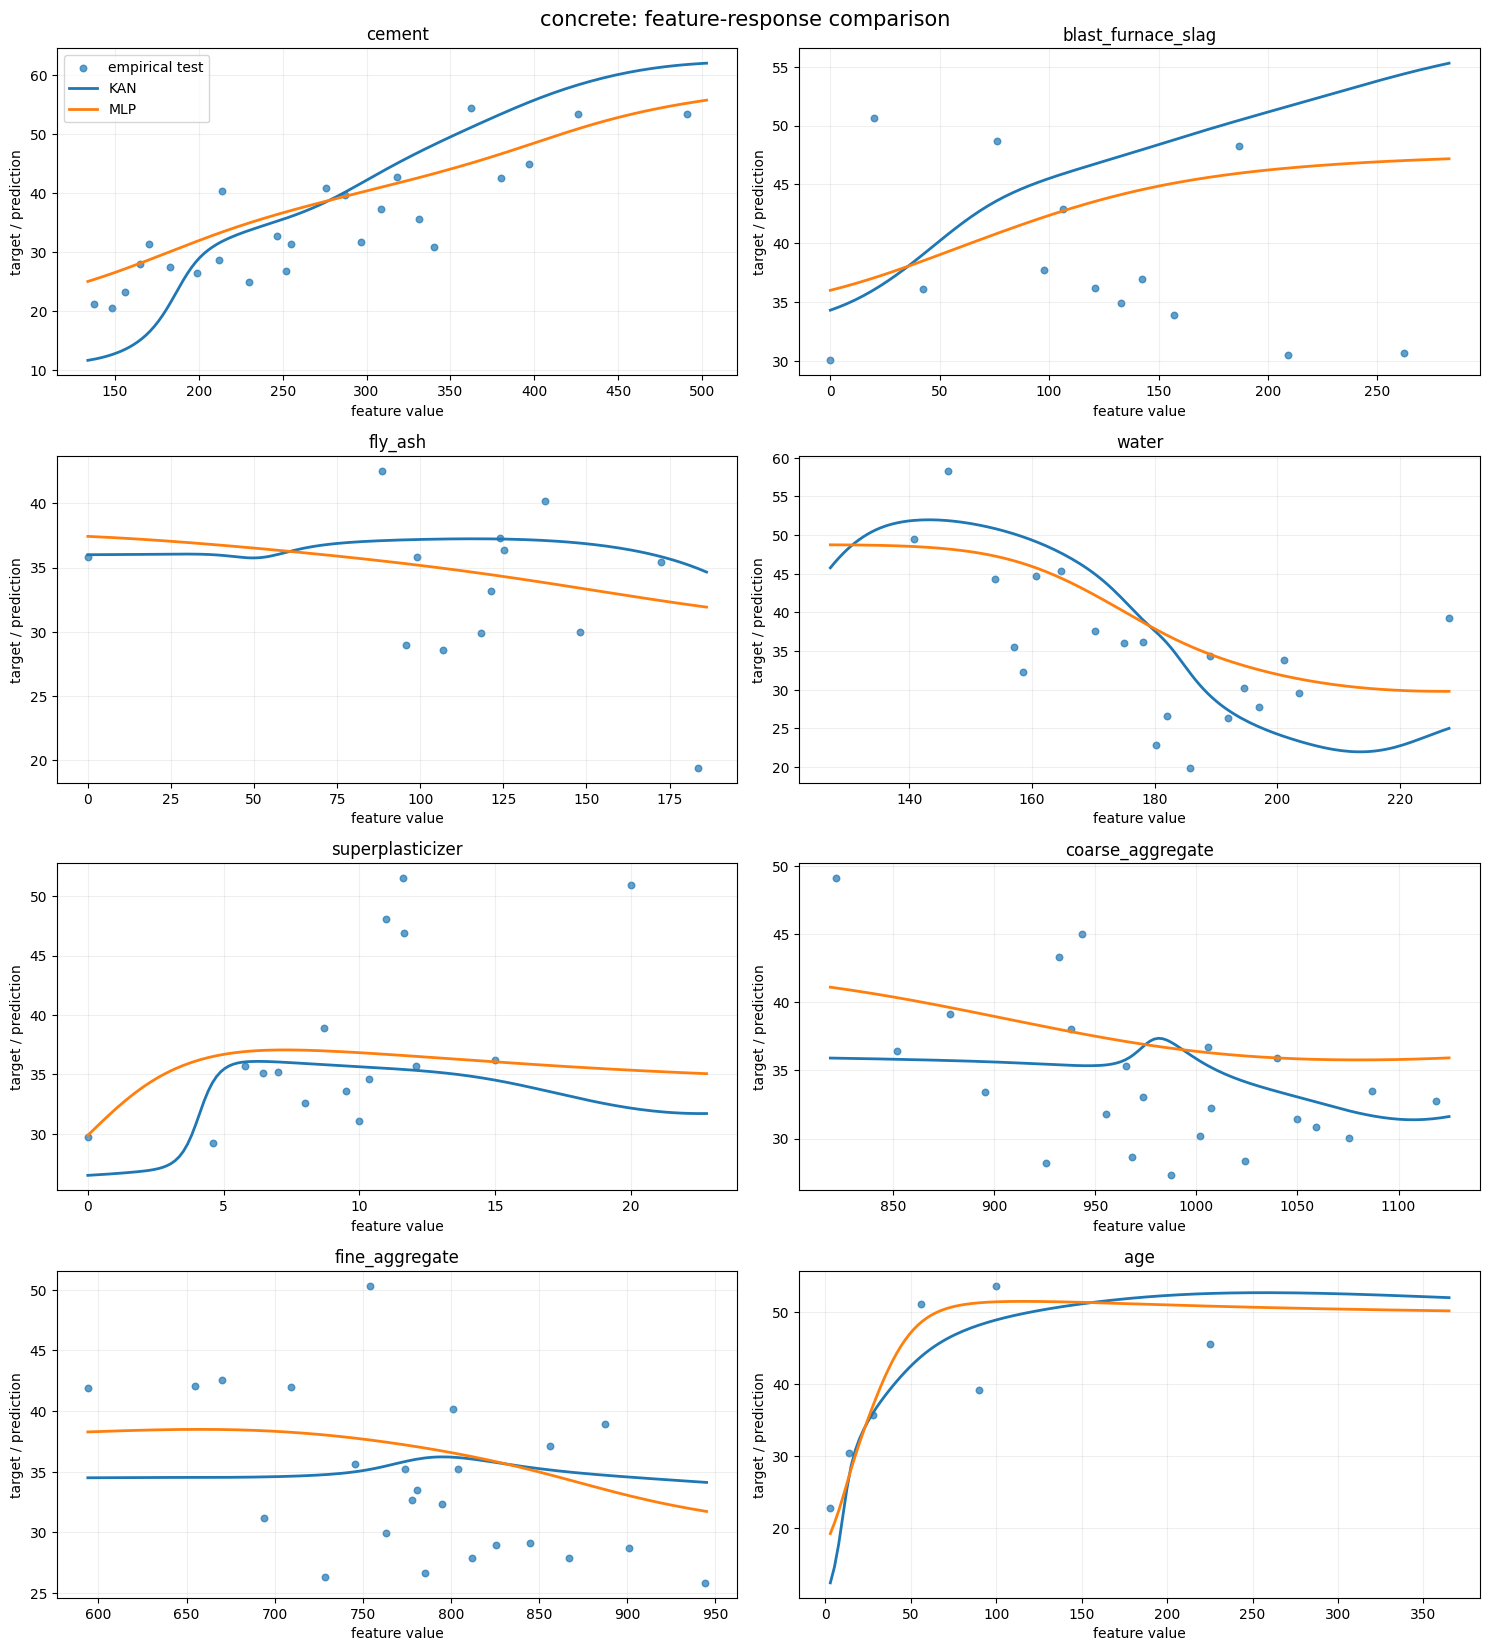


DATASET: abalone
Loaded: rows=4,177, features=10, task=regression


 75%|███████▌  | 45/60 [00:03<00:01, 13.63it/s]



CV results:


,fold,params,epochs,time_sec,rmse,r2
model,,,,,,
KAN,2.0,139209.0,43.00000,7.53816,2.16798,0.54654
MLP,2.0,137729.0,53.66667,3.88057,2.14625,0.55577


Feature-response plots:


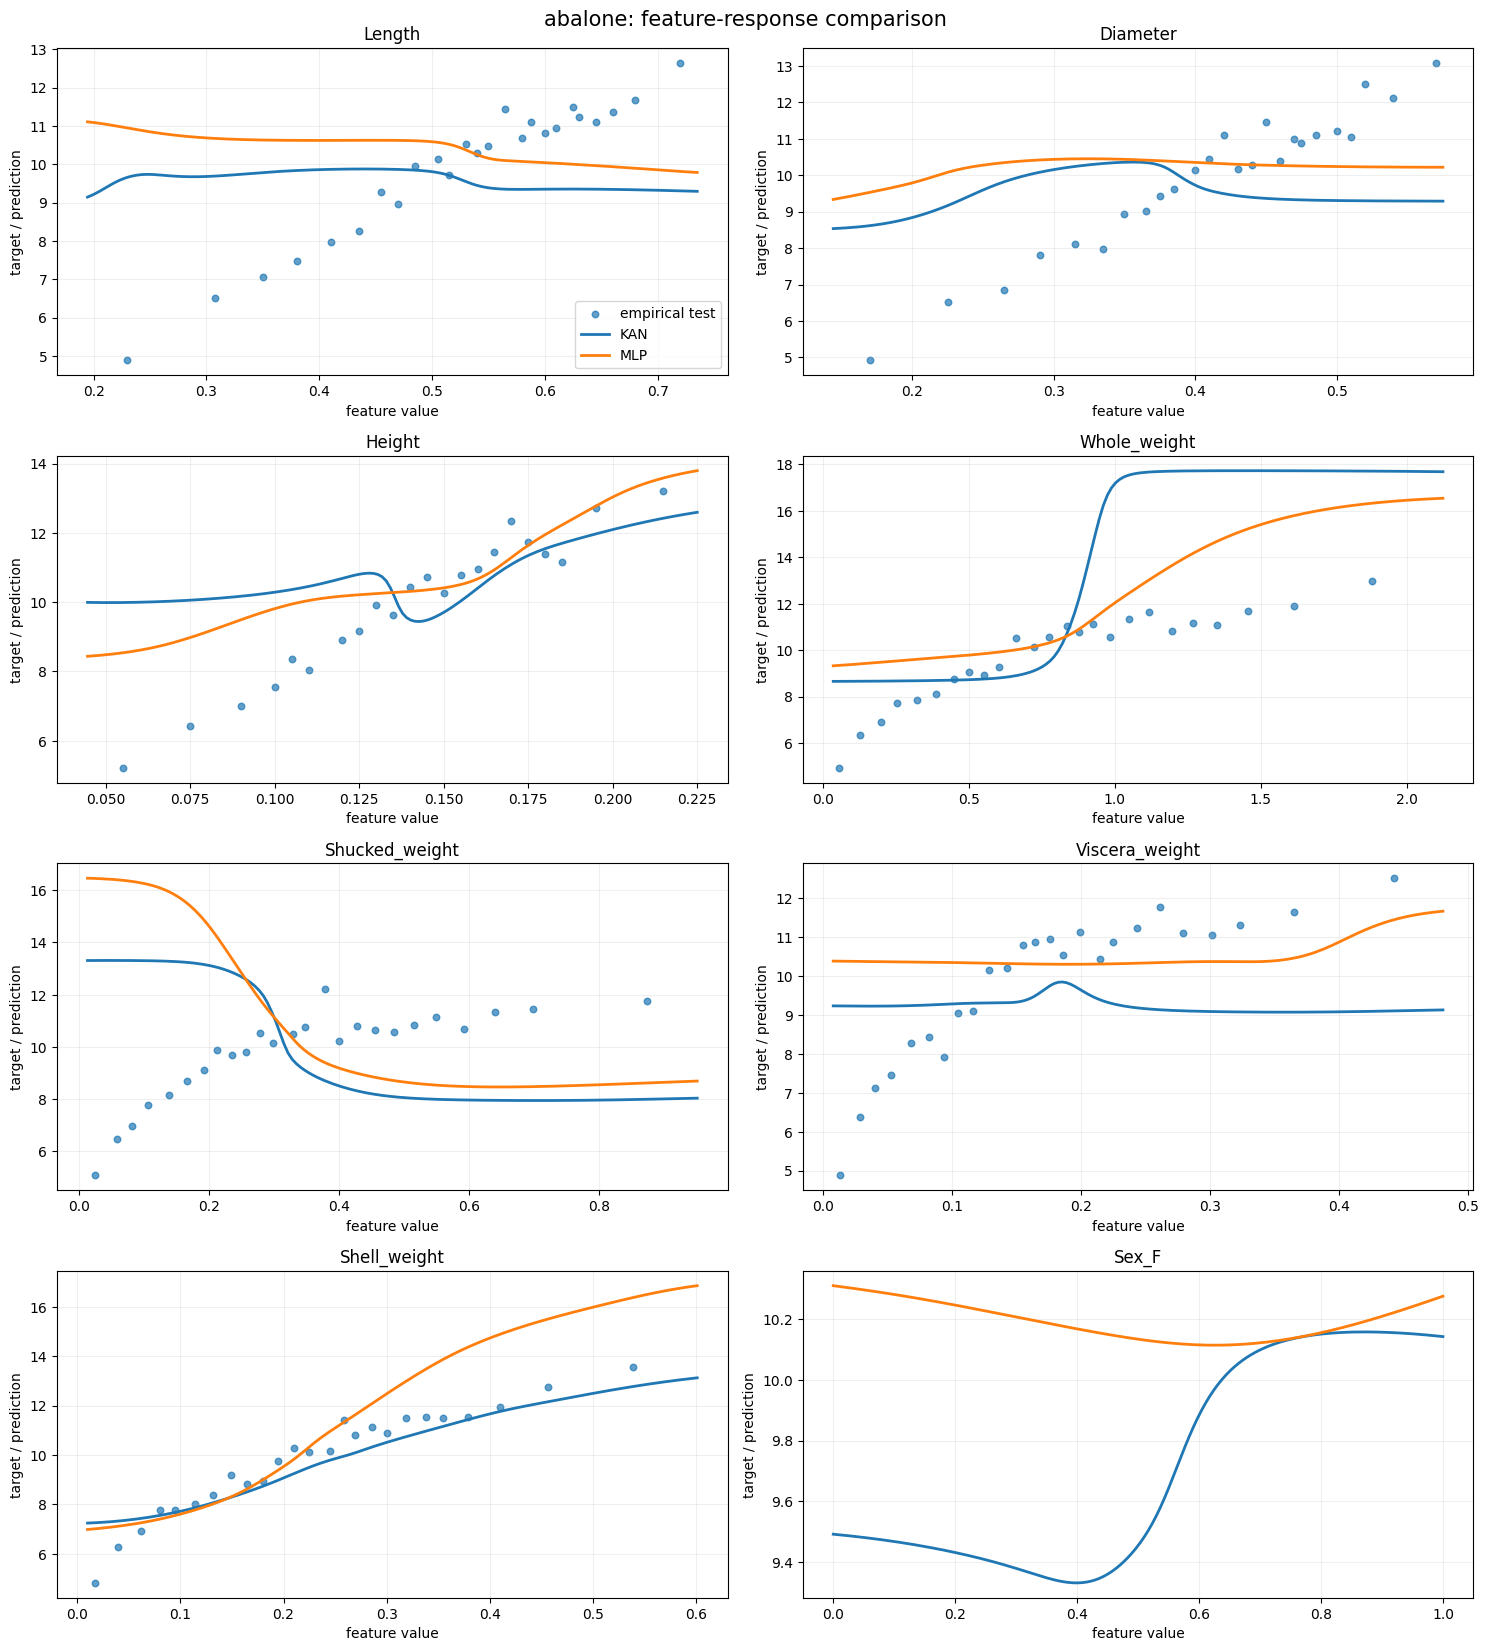


=== Mean CV results ===


,dataset,model,fold,params,epochs,time_sec,auc,rmse,r2
0,abalone,KAN,2.0,139209.0,43.00000,7.53816,NaN,2.16798,0.54654
1,abalone,MLP,2.0,137729.0,53.66667,3.88057,NaN,2.14625,0.55577
2,airfoil,KAN,2.0,121989.0,60.00000,3.67297,NaN,2.04635,0.91122
3,airfoil,MLP,2.0,121249.0,60.00000,1.70530,NaN,2.03366,0.91249
4,breast_cancer,KAN,2.0,208154.0,36.33333,4.37087,0.99320,NaN,NaN
5,breast_cancer,MLP,2.0,203714.0,33.66667,1.09233,0.99332,NaN,NaN
6,ccpp,KAN,2.0,118545.0,53.33333,10.95627,NaN,4.01247,0.94471
7,ccpp,MLP,2.0,117953.0,60.00000,7.96898,NaN,3.99058,0.94532
8,concrete,KAN,2.0,132321.0,60.00000,3.83256,NaN,5.92315,0.87374
9,concrete,MLP,2.0,131137.0,49.66667,1.39796,NaN,6.49403,0.84746



Successful: ['magic', 'airfoil', 'breast_cancer', 'diabetes_cdc', 'ccpp', 'concrete', 'abalone']
Failed: {}


In [13]:
all_real_results = []
real_artifacts = {}
failed_datasets = {}

for name in [x for x in RUN_DATASETS if x != "feynman"]:
    print("\n" + "=" * 70)
    print("DATASET:", name)

    try:
        X0, y0, task0 = load_dataset(name)
        print(
            f"Loaded: rows={len(X0):,}, "
            f"features={X0.shape[1]}, task={task0}"
        )

        result_df, artifact = run_real_dataset(name)

        all_real_results.append(result_df)
        real_artifacts[name] = artifact

        print("\nCV results:")
        display(
            result_df.groupby("model")
            .mean(numeric_only=True)
            .round(5)
        )

        result_df.to_csv(
            OUT_DIR / f"{name}_fold_results.csv",
            index=False
        )

        print("Feature-response plots:")
        plot_real_feature_curves(
            artifact,
            name,
            max_features=min(8, len(artifact["feature_names"]))
        )

    except Exception as e:
        failed_datasets[name] = (
            f"{type(e).__name__}: {e}"
        )
        print(
            "FAILED:",
            failed_datasets[name]
        )

if all_real_results:
    real_results = pd.concat(
        all_real_results,
        ignore_index=True
    )
    real_results.to_csv(
        OUT_DIR / "real_results.csv",
        index=False
    )

    print("\n=== Mean CV results ===")
    display(
        real_results.groupby(
            ["dataset", "model"]
        )
        .mean(numeric_only=True)
        .reset_index()
        .round(5)
    )

print("\nSuccessful:", list(real_artifacts.keys()))
print("Failed:", failed_datasets)

# 10. Feynman Physics — exact formula ground truth

Для Feynman используем публичную таблицу `FeynmanEquations.csv`.

Notebook автоматически:
1. выбирает формулы, которые можно безопасно вычислить;
2. генерирует данные непосредственно из формулы;
3. обучает KAN и MLP;
4. считает test RMSE/R²;
5. для **каждого признака** строит один график:

**EXACT formula — чёрная пунктирная**  
**KAN prediction**  
**MLP prediction**

В отличие от предыдущей версии, модели обучаются **один раз на уравнение**, а не заново для каждого признака.

In [14]:
FEYNMAN_URL = (
    "https://huggingface.co/spaces/MilesCranmer/PySR/resolve/"
    "6e2fc47a46ef3c644c333a73d17fcc4b5d9c115f/datasets/FeynmanEquations.csv"
)

def load_feynman_catalog():
    return pd.read_csv(FEYNMAN_URL)


def safe_formula_eval(formula, variables, X):
    local = {
        "sqrt": np.sqrt,
        "exp": np.exp,
        "sin": np.sin,
        "cos": np.cos,
        "tan": np.tan,
        "log": np.log,
        "ln": np.log,
        "log10": np.log10,
        "abs": np.abs,
        "Abs": np.abs,
        "arcsin": np.arcsin,
        "arccos": np.arccos,
        "arctan": np.arctan,
        "sinh": np.sinh,
        "cosh": np.cosh,
        "tanh": np.tanh,
        "pi": np.pi,
        "E": np.e,
        "G": 1.0,
    }

    for j, var in enumerate(variables):
        local[var] = X[:, j]

    return np.asarray(
        eval(formula, {"__builtins__": {}}, local),
        dtype=float
    )


def load_feynman_equation(row):
    nvar = int(row["# variables"])

    variables = [
        row[f"v{i}_name"]
        for i in range(1, nvar + 1)
    ]

    lows = [
        float(row[f"v{i}_low"])
        for i in range(1, nvar + 1)
    ]

    highs = [
        float(row[f"v{i}_high"])
        for i in range(1, nvar + 1)
    ]

    rng = np.random.default_rng(SEED)

    X = np.column_stack([
        rng.uniform(lo, hi, size=FEYNMAN_SAMPLES)
        for lo, hi in zip(lows, highs)
    ])

    y = safe_formula_eval(
        row["Formula"],
        variables,
        X
    )

    mask = (
        np.isfinite(X).all(axis=1) &
        np.isfinite(y)
    )

    X = X[mask]
    y = y[mask]

    return (
        pd.DataFrame(X, columns=variables),
        pd.Series(y, name="target"),
        {
            "id": row["Filename"],
            "formula": row["Formula"],
            "variables": variables,
            "ranges": list(zip(lows, highs))
        }
    )


catalog = load_feynman_catalog()
print("Feynman catalog:", catalog.shape)
display(
    catalog[
        ["Filename", "Formula", "# variables", "datapoints"]
    ].head(10)
)

Feynman catalog: (100, 36)


,Filename,Formula,# variables,datapoints
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),1,10
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2,100
2,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3,1000
3,I.8.14,sqrt((x2-x1)**2+(y2-y1)**2),4,100
4,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),9,1000000
5,I.10.7,m_0/sqrt(1-v**2/c**2),3,10
6,I.11.19,x1*y1+x2*y2+x3*y3,6,100
7,I.12.1,mu*Nn,2,10
8,I.12.2,q1*q2*r/(4*pi*epsilon*r**3),4,10
9,I.12.4,q1*r/(4*pi*epsilon*r**3),3,10


## 11. Выбор Feynman equations

Если `FEYNMAN_IDS=None`, выбираем первые несколько формул, которые:
- содержат не более 3 переменных;
- корректно вычисляются;
- дают конечные значения.

Это предотвращает падение всего notebook из-за одной неудобной формулы.

In [15]:
def choose_feynman_rows(catalog):
    if FEYNMAN_IDS is not None:
        rows = catalog[
            catalog["Filename"].isin(FEYNMAN_IDS)
        ].copy()

        if len(rows) == 0:
            raise ValueError(
                "FEYNMAN_IDS задан, но ни один Filename не найден."
            )
        return rows.reset_index(drop=True)

    selected = []

    for _, row in catalog.iterrows():
        try:
            if int(row["# variables"]) > 3:
                continue

            # We generate FEYNMAN_SAMPLES ourselves, so even catalogue
            # rows with only a few original datapoints can be used.
            _, y, _ = load_feynman_equation(row)

            if not np.isfinite(y.to_numpy()).all():
                continue

            selected.append(row)

            if len(selected) >= N_FEYNMAN_EQUATIONS:
                break

        except Exception:
            continue

    if not selected:
        raise RuntimeError(
            "Could not find a safely evaluable Feynman subset."
        )

    return pd.DataFrame(selected).reset_index(drop=True)


feynman_rows = choose_feynman_rows(catalog)

display(
    feynman_rows[
        ["Filename", "Formula", "# variables", "datapoints"]
    ]
)

,Filename,Formula,# variables,datapoints
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),1,10
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2,100
2,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3,1000


## 12. Обучение Feynman

Здесь особенно важно не превращать задачу в предсказание среднего.

Поэтому:
- X стандартизируется;
- **y тоже стандартизируется по train**;
- используется отдельный более длинный training budget;
- KAN grid = `[-3, 3]`;
- после обучения prediction возвращается в физический масштаб формулы.

In [16]:
def train_feynman_equation(X, y, kind):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    idx = np.arange(len(X))

    train_idx, test_idx = train_test_split(
        idx,
        test_size=0.20,
        random_state=SEED
    )

    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=0.15,
        random_state=SEED
    )

    fit = train_single_fold(
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx],
        "regression",
        kind,
        FEYNMAN_EPOCHS,
        FEYNMAN_PATIENCE,
        seed=SEED
    )

    return fit, train_idx, val_idx, test_idx


def feynman_curve(
    fit, X_test, feature_idx,
    exact_meta
):
    model = fit["model"]
    x_scaler = fit["x_scaler"]
    y_scaler = fit["y_scaler"]

    X_test = np.asarray(X_test, dtype=float)

    lo, hi = np.percentile(
        X_test[:, feature_idx],
        [1, 99]
    )
    grid = np.linspace(
        lo, hi, N_CURVE_POINTS
    )

    base = np.median(
        X_test,
        axis=0
    )

    Xcurve = np.repeat(
        base[None, :],
        len(grid),
        axis=0
    )
    Xcurve[:, feature_idx] = grid

    Xscaled = x_scaler.transform(
        Xcurve
    ).astype(np.float32)

    outputs = predict_outputs(
        model,
        Xscaled
    )

    pred = (
        outputs.reshape(-1)
        * y_scaler[1]
        + y_scaler[0]
    )

    exact_X = Xcurve.copy()
    exact = safe_formula_eval(
        exact_meta["formula"],
        exact_meta["variables"],
        exact_X
    )

    return grid, pred, exact


def run_feynman():
    rows = []
    curve_rows = []
    artifacts = {}

    for _, row in feynman_rows.iterrows():
        Xdf, y, meta = load_feynman_equation(row)

        X = Xdf.to_numpy(dtype=float)
        y = y.to_numpy(dtype=float)

        print("\n" + "=" * 70)
        print(meta["id"])
        print("Formula:", meta["formula"])

        fits = {}

        for kind in ["KAN", "MLP"]:
            fit, train_idx, val_idx, test_idx = train_feynman_equation(
                X, y, kind
            )
            fits[kind] = fit

            rows.append({
                "equation": meta["id"],
                "formula": meta["formula"],
                "model": kind,
                **fit["test_metric"],
                "params": fit["params"],
                "epochs": fit["epochs_used"]
            })

            print(
                kind,
                fit["test_metric"],
                "epochs=", fit["epochs_used"]
            )

        artifacts[meta["id"]] = {
            "meta": meta,
            "X": X,
            "y": y,
            "test_idx": test_idx,
            "fits": fits
        }

        # Exact-vs-prediction curves for every feature.
        for j, feature in enumerate(meta["variables"]):
            for kind in ["KAN", "MLP"]:
                grid, pred, exact = feynman_curve(
                    fits[kind],
                    X[test_idx],
                    j,
                    meta
                )

                curve_rmse = float(
                    np.sqrt(
                        mean_squared_error(
                            exact, pred
                        )
                    )
                )

                curve_r2 = float(
                    r2_score(
                        exact, pred
                    )
                )

                curve_rows.append({
                    "equation": meta["id"],
                    "formula": meta["formula"],
                    "feature": feature,
                    "model": kind,
                    "curve_rmse": curve_rmse,
                    "curve_r2": curve_r2
                })

    return (
        pd.DataFrame(rows),
        pd.DataFrame(curve_rows),
        artifacts
    )


if "feynman" in RUN_DATASETS:
    feynman_results, feynman_curves, feynman_artifacts = run_feynman()

    feynman_results.to_csv(
        OUT_DIR / "feynman_results.csv",
        index=False
    )
    feynman_curves.to_csv(
        OUT_DIR / "feynman_curve_truth.csv",
        index=False
    )

    print("\n=== Feynman test metrics ===")
    display(feynman_results.round(6))

    print("\n=== Curve vs exact formula ===")
    display(feynman_curves.round(6))


I.6.2a
Formula: exp(-theta**2/2)/sqrt(2*pi)


 41%|████      | 74/180 [00:12<00:18,  5.82it/s]


KAN {'rmse': 0.0006543445331512698, 'r2': 0.9999146256128235} epochs= 75


 37%|███▋      | 66/180 [00:09<00:17,  6.61it/s]


MLP {'rmse': 0.0005723242276921776, 'r2': 0.9999346871095056} epochs= 67

I.6.2
Formula: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)


...

 75%|███████▌  | 135/180 [00:22<00:07,  6.08it/s]


MLP {'rmse': 0.0011879999292171508, 'r2': 0.999621509842187} epochs= 136

=== Feynman test metrics ===


,equation,formula,model,rmse,r2,params,epochs
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),KAN,0.000654,0.999915,108213,75
1,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),MLP,0.000572,0.999935,108065,67
2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),KAN,0.000753,0.999691,111657,97
3,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),MLP,0.000510,0.999858,111361,97
4,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,KAN,0.001465,0.999424,115101,93
5,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,MLP,0.001188,0.999622,114657,136



=== Curve vs exact formula ===


,equation,formula,feature,model,curve_rmse,curve_r2
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),theta,KAN,0.000638,0.999915
1,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),theta,MLP,0.000544,0.999938
2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),sigma,KAN,0.000319,0.999588
3,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),sigma,MLP,0.000339,0.999534
4,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),theta,KAN,0.000590,0.999709
5,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),theta,MLP,0.000486,0.999803
6,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,sigma,KAN,0.001018,0.999787
7,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,sigma,MLP,0.000737,0.999888
8,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,theta,KAN,0.000448,0.996414
9,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,theta,MLP,0.000494,0.995651


## 13. Главный Feynman-график: Exact formula vs prediction

Для каждого выбранного уравнения строится отдельный график по каждому признаку.

Другие признаки фиксируются на **медиане test set**. Поэтому это controlled one-feature response, а не causal effect.

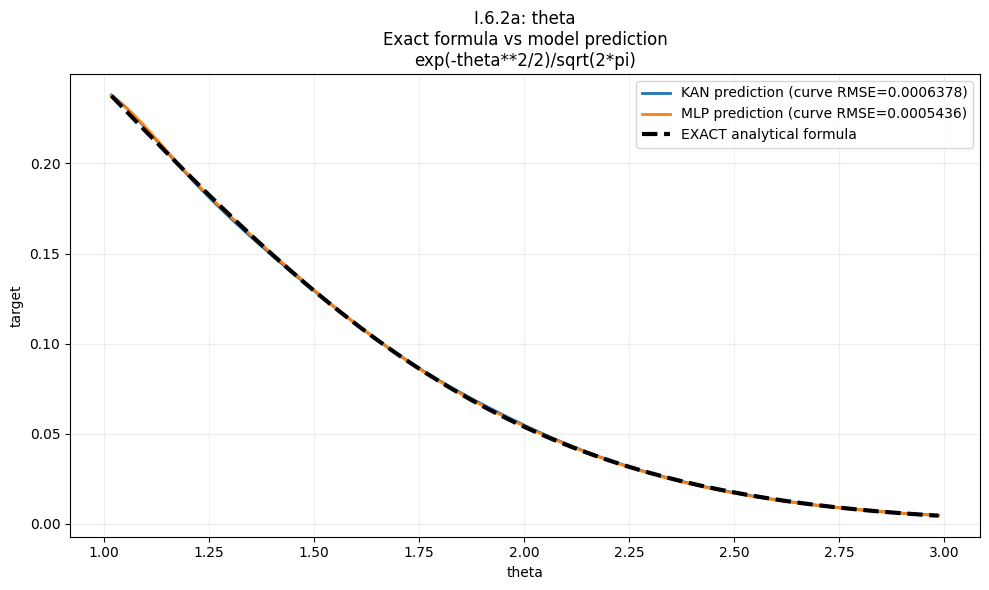

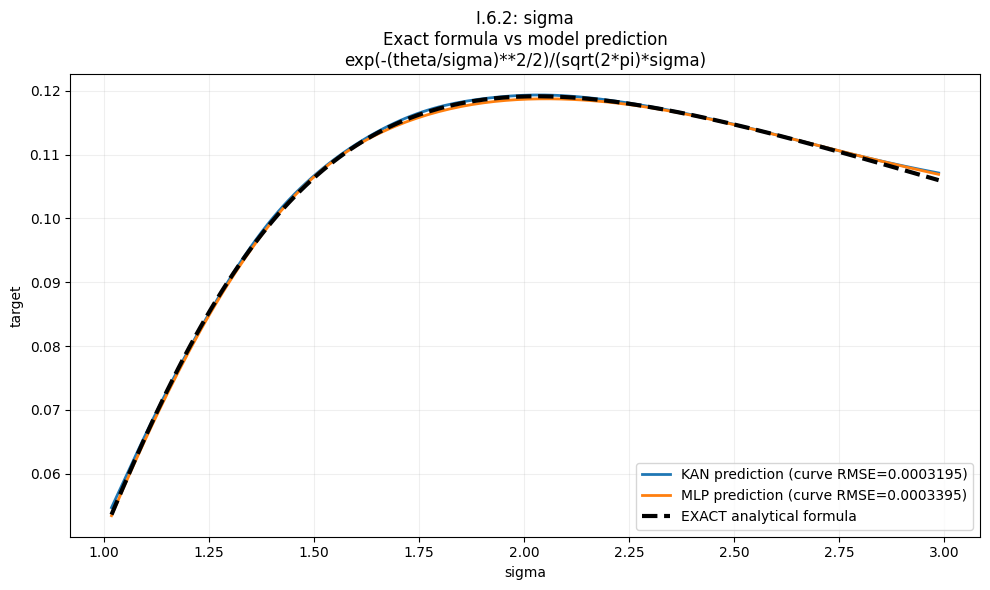

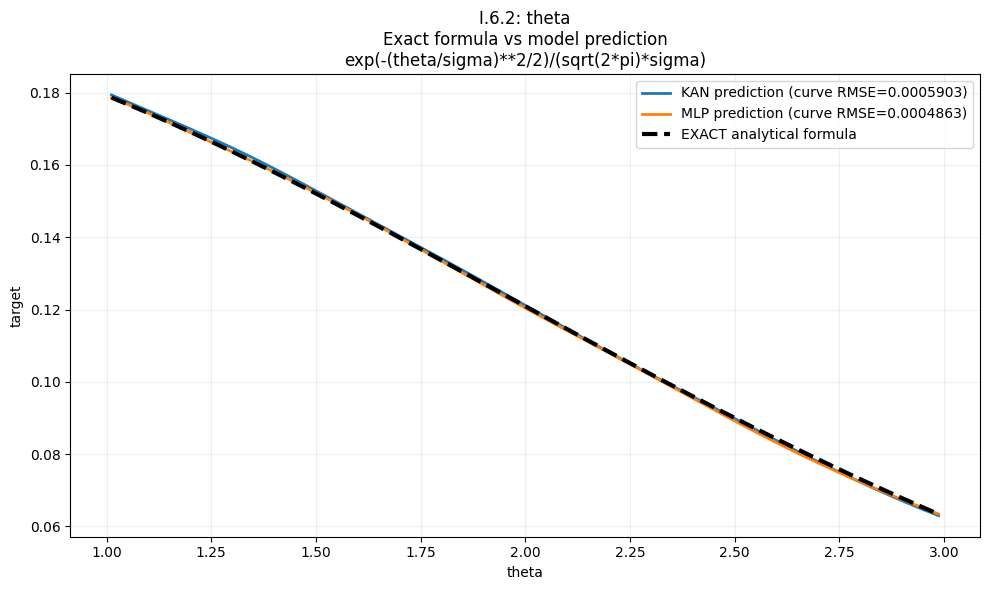

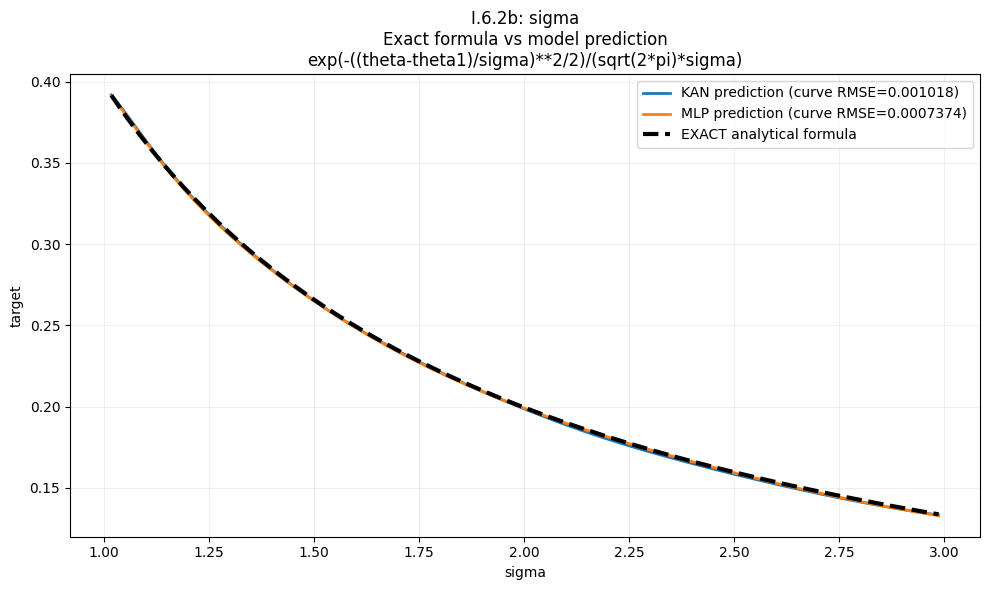

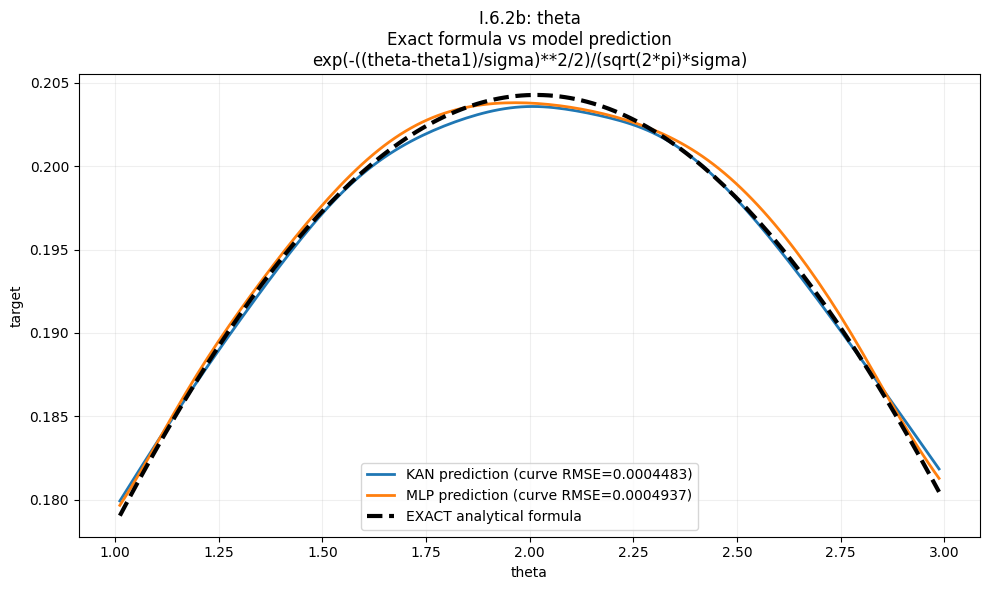

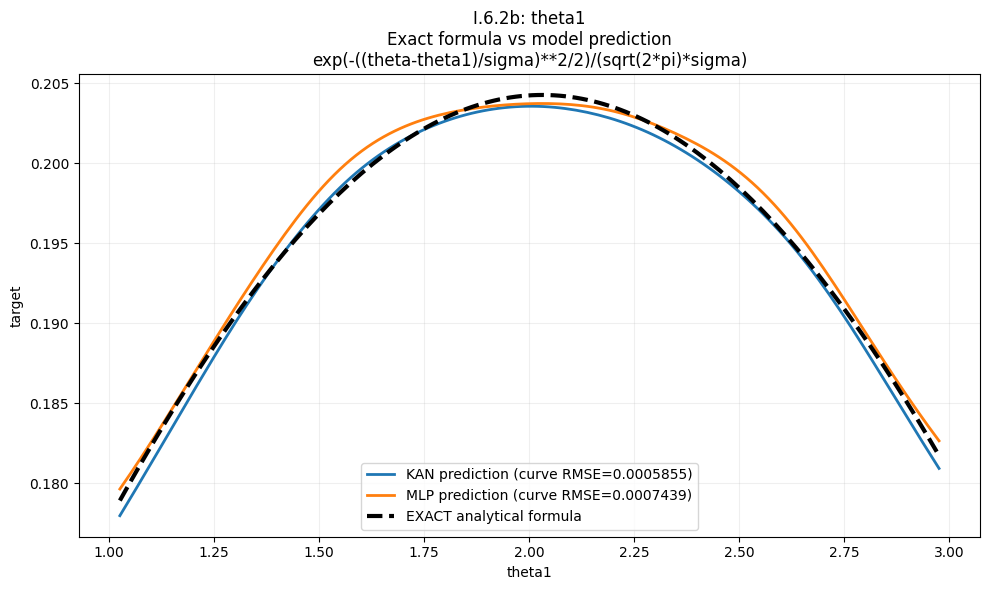

In [17]:
def plot_all_feynman_curves(artifacts):
    for eq_id, art in artifacts.items():
        meta = art["meta"]
        X = art["X"]
        test_idx = art["test_idx"]

        for j, feature in enumerate(meta["variables"]):
            plt.figure(figsize=(10, 6))

            # Exact + models
            for kind in ["KAN", "MLP"]:
                grid, pred, exact = feynman_curve(
                    art["fits"][kind],
                    X[test_idx],
                    j,
                    meta
                )

                curve_rmse = float(
                    np.sqrt(
                        mean_squared_error(
                            exact, pred
                        )
                    )
                )

                plt.plot(
                    grid,
                    pred,
                    linewidth=2,
                    label=(
                        f"{kind} prediction "
                        f"(curve RMSE={curve_rmse:.4g})"
                    )
                )

            plt.plot(
                grid,
                exact,
                "k--",
                linewidth=3,
                label="EXACT analytical formula"
            )

            plt.xlabel(feature)
            plt.ylabel("target")
            plt.title(
                f"{eq_id}: {feature}\n"
                f"Exact formula vs model prediction\n"
                f"{meta['formula']}"
            )
            plt.grid(alpha=0.2)
            plt.legend()
            plt.tight_layout()
            plt.show()


if "feynman" in RUN_DATASETS:
    plot_all_feynman_curves(feynman_artifacts)

## 14. Сводные таблицы

Для regression:
- **RMSE ↓**
- **R² ↑**

Для binary classification:
- **ROC-AUC ↑**

Для multiclass:
- **macro-F1 ↑**

Важно: в таблице используются средние по folds. Визуализация берёт лучший fold только для наглядности; это не меняет CV-метрики.

In [27]:
if "real_results" in globals() and len(real_results) > 0:
    print("=== REAL DATA ===")

    # Какие метрики реально есть в таблице?
    metric_cols = [c for c in ["rmse", "r2", "auc", "macro_f1"]
                   if c in real_results.columns]
    print("Available metric columns:", metric_cols)

    # Собираем agg-словарь динамически
    agg_dict = {f"mean_{c}": (c, "mean") for c in metric_cols}
    agg_dict["mean_epochs"] = ("epochs", "mean")
    agg_dict["mean_params"] = ("params", "mean")

    real_summary = (
        real_results
        .groupby(["dataset", "model"])
        .agg(**agg_dict)
        .reset_index()
    )

    display(real_summary.round(5))

    # Compact comparison по датасетам
    for dataset in real_results["dataset"].unique():
        tmp = real_results[real_results["dataset"] == dataset]
        print(f"\n--- {dataset} ---")
        display(
            tmp.groupby("model")
            .mean(numeric_only=True)
            .round(5)
        )

=== REAL DATA ===
Available metric columns: ['rmse', 'r2', 'auc']


,dataset,model,mean_rmse,mean_r2,mean_auc,mean_epochs,mean_params
0,abalone,KAN,2.16798,0.54654,NaN,43.00000,139209.0
1,abalone,MLP,2.14625,0.55577,NaN,53.66667,137729.0
2,airfoil,KAN,2.04635,0.91122,NaN,60.00000,121989.0
3,airfoil,MLP,2.03366,0.91249,NaN,60.00000,121249.0
4,breast_cancer,KAN,NaN,NaN,0.99320,36.33333,208154.0
5,breast_cancer,MLP,NaN,NaN,0.99332,33.66667,203714.0
6,ccpp,KAN,4.01247,0.94471,NaN,53.33333,118545.0
7,ccpp,MLP,3.99058,0.94532,NaN,60.00000,117953.0
8,concrete,KAN,5.92315,0.87374,NaN,60.00000,132321.0
9,concrete,MLP,6.49403,0.84746,NaN,49.66667,131137.0



--- magic ---


,fold,params,epochs,time_sec,auc,rmse,r2
model,,,,,,,
KAN,2.0,139274.0,41.33333,32.80784,0.92910,NaN,NaN
MLP,2.0,137794.0,42.00000,13.68141,0.93082,NaN,NaN



--- airfoil ---


...

,fold,params,epochs,time_sec,auc,rmse,r2
model,,,,,,,
KAN,2.0,118545.0,53.33333,10.95627,NaN,4.01247,0.94471
MLP,2.0,117953.0,60.00000,7.96898,NaN,3.99058,0.94532



--- concrete ---


,fold,params,epochs,time_sec,auc,rmse,r2
model,,,,,,,
KAN,2.0,132321.0,60.00000,3.83256,NaN,5.92315,0.87374
MLP,2.0,131137.0,49.66667,1.39796,NaN,6.49403,0.84746



--- abalone ---


,fold,params,epochs,time_sec,auc,rmse,r2
model,,,,,,,
KAN,2.0,139209.0,43.00000,7.53816,NaN,2.16798,0.54654
MLP,2.0,137729.0,53.66667,3.88057,NaN,2.14625,0.55577


## 15. Сохранение результатов

В папке `tabkanet_tabmlpnet_results/` будут:
- fold-level результаты каждого real dataset;
- `real_results.csv`;
- `feynman_results.csv`;
- `feynman_curve_truth.csv`.

Формулы Feynman **не объявляются восстановленными символьно**: здесь проверяется только совпадение learned response с известной аналитической функцией.

In [20]:
# Save metadata about the run
run_info = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "n_folds": N_FOLDS,
    "epochs": EPOCHS,
    "feynman_epochs": FEYNMAN_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "datasets": RUN_DATASETS,
}

pd.Series(run_info).to_json(
    OUT_DIR / "run_config.json",
    force_ascii=False,
    indent=2
)

# Create a zip for easy download from Colab.
import shutil
zip_path = shutil.make_archive(
    "tabkanet_tabmlpnet_results",
    "zip",
    OUT_DIR
)

print("Results directory:", OUT_DIR.resolve())
print("ZIP:", Path(zip_path).resolve())

Results directory: D:\Documents\Downloads\tabkanet_tabmlpnet_results
ZIP: D:\Documents\Downloads\tabkanet_tabmlpnet_results.zip


In [35]:
# ============================================================
# Выход feature-wise KAN-энкодера внутри TabKANet
# Для пары выбранных признаков: mean, norm и PCA-траектория
# ============================================================



def kan_encoder_forward_1d(kan_encoder, feature_idx, grid_scaled):
    """
    Прогон ТОЛЬКО KAN_i на одномерных значениях признака i.
    Автоматически переносит вход на тот же device, где лежат веса.
    """
    kan_i = kan_encoder.models[feature_idx]
    device = next(kan_i.parameters()).device   # ← ключевая строка

    x = torch.tensor(grid_scaled, dtype=torch.float32,
                     device=device).reshape(-1, 1)
    with torch.no_grad():
        out = kan_i(x).cpu().numpy()
    return out  # (n_points, d_model)


def kan_encoder_curve(kan_model, x_scaler, X_reference, feature_idx,
                      n_points=200):
    """
    Возвращает grid (в оригинальной шкале), mean и norm от phi_i(x_i).
    """
    X_reference = np.asarray(X_reference, dtype=float)
    lo, hi = np.percentile(X_reference[:, feature_idx], [1, 99])
    grid_original = np.linspace(lo, hi, n_points)

    # Стандартизуем grid так же, как KAN видел при обучении
    fake = np.tile(x_scaler.mean_, (n_points, 1))
    fake[:, feature_idx] = grid_original
    fake_scaled = x_scaler.transform(fake).astype(np.float32)

    grid_scaled = fake_scaled[:, feature_idx]  # (n_points,)

    phi = kan_encoder_forward_1d(
        kan_model.encoder, feature_idx, grid_scaled
    )  # (n_points, d_model)

    phi_mean = phi.mean(axis=1)
    phi_norm = np.linalg.norm(phi, axis=1)

    return grid_original, phi_mean, phi_norm, phi


def mlp_encoder_curve(mlp_model, x_scaler, X_reference, feature_idx,
                      n_points=200):
    X_reference = np.asarray(X_reference, dtype=float)
    lo, hi = np.percentile(X_reference[:, feature_idx], [1, 99])
    grid_original = np.linspace(lo, hi, n_points)

    fake = np.tile(x_scaler.mean_, (n_points, 1))
    fake[:, feature_idx] = grid_original
    fake_scaled = x_scaler.transform(fake).astype(np.float32)
    grid_scaled = fake_scaled[:, feature_idx]

    mlp_i = mlp_model.encoder.models[feature_idx]
    device = next(mlp_i.parameters()).device   # ← то же исправление

    x = torch.tensor(grid_scaled, dtype=torch.float32,
                     device=device).reshape(-1, 1)
    with torch.no_grad():
        phi = mlp_i(x).cpu().numpy()

    return grid_original, phi.mean(axis=1), np.linalg.norm(phi, axis=1), phi


def plot_tabkanet_encoder_outputs(artifact, dataset_name,
                                  feature_indices=None,
                                  n_points=200):
    """
    Рисует для каждого выбранного признака:
      - левая панель: φ_i(x_i) скаляризованное (mean по d_model)
        KAN vs MLP
      - правая панель: PCA-траектория φ_i(x_i) для KAN и MLP,
        окрашенная по x_i
    """
    X_test = artifact["X_test"]
    feature_names = artifact["feature_names"]

    if feature_indices is None:
        feature_indices = list(range(min(4, len(feature_names))))

    n = len(feature_indices)
    fig, axes = plt.subplots(n, 2, figsize=(15, 3.8 * n))
    if n == 1:
        axes = np.asarray([axes])

    kan_model = artifact["models"]["KAN"]
    mlp_model = artifact["models"]["MLP"]
    kan_x_scaler = artifact["x_scalers"]["KAN"]
    mlp_x_scaler = artifact["x_scalers"]["MLP"]

    for row, j in enumerate(feature_indices):
        # --- KAN encoder ---
        gx, kan_mean, kan_norm, kan_phi = kan_encoder_curve(
            kan_model, kan_x_scaler, X_test, j, n_points
        )
        # --- MLP encoder ---
        _, mlp_mean, mlp_norm, mlp_phi = mlp_encoder_curve(
            mlp_model, mlp_x_scaler, X_test, j, n_points
        )

        # ---------- Левая панель: mean по d_model ----------
        ax = axes[row, 0]
        ax.plot(gx, kan_mean, "r-", lw=2,
                label=r"KAN $\phi_i(x_i)$ — mean over $d_{model}$")
        ax.plot(gx, mlp_mean, "b--", lw=2,
                label=r"MLP $\phi_i(x_i)$ — mean over $d_{model}$")
        ax.set_xlabel(feature_names[j])
        ax.set_ylabel(r"mean of $\phi_i(x_i)$")
        ax.set_title(f"{dataset_name} — encoder output (mean), feature: {feature_names[j]}")
        ax.grid(alpha=0.3)
        ax.legend()


    plt.tight_layout()
    plt.show()



abalone: 10 features
feature_names = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_F', 'Sex_I', 'Sex_M']


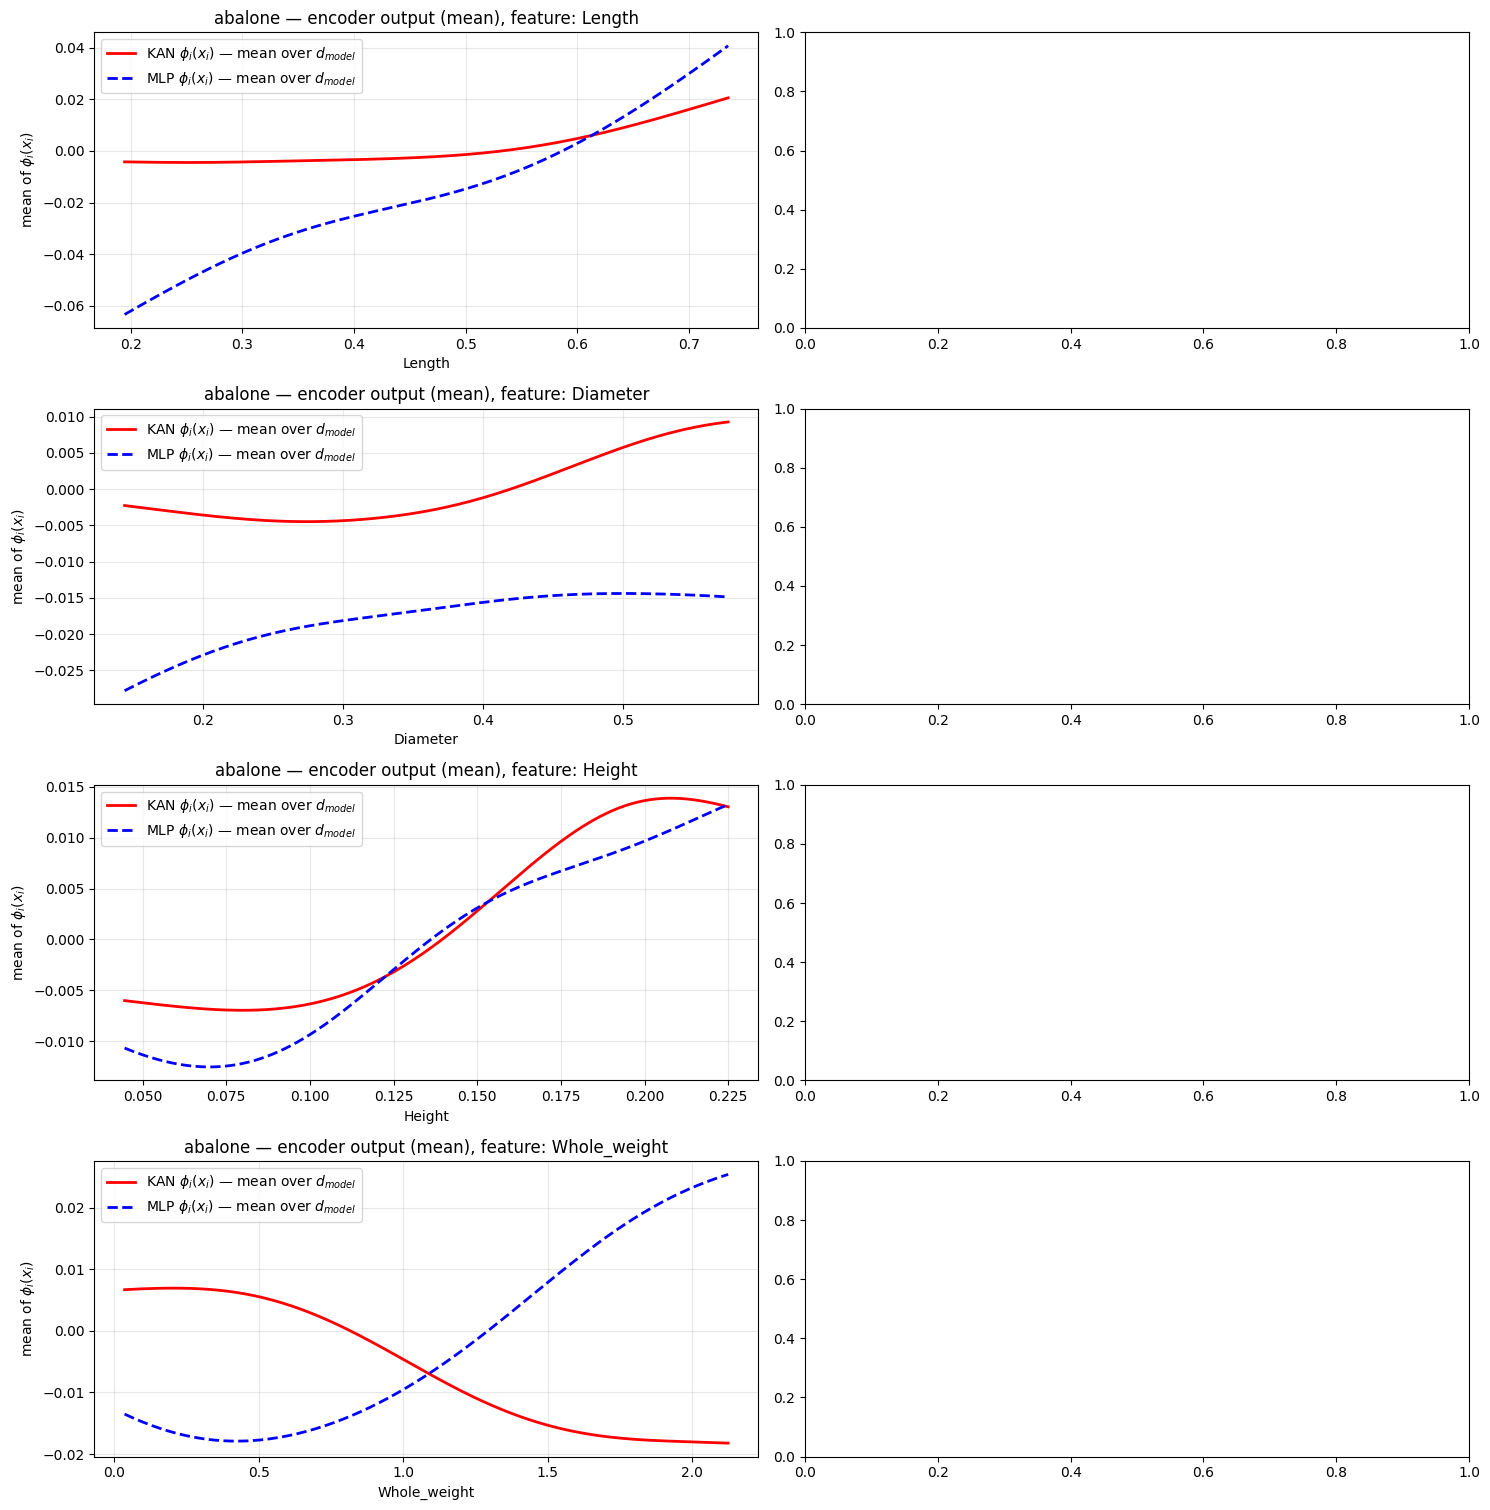

In [36]:
# Выбираем любой датасет из успешных
DATASET_NAME = "abalone"   # или "ccpp", "concrete", "abalone"

if DATASET_NAME in real_artifacts:
    artifact = real_artifacts[DATASET_NAME]
    feature_names = artifact["feature_names"]
    print(f"{DATASET_NAME}: {len(feature_names)} features")
    print(f"feature_names = {feature_names}")

    # --- Скалярные кривые + PCA-траектории ---
    plot_tabkanet_encoder_outputs(
        artifact, DATASET_NAME,
        feature_indices=list(range(min(4, len(feature_names)))),
        n_points=200,
    )
else:
    print(f"{DATASET_NAME} не найден. Доступные: {list(real_artifacts.keys())}")

ccpp: 4 features
feature_names = ['AT', 'V', 'AP', 'RH']


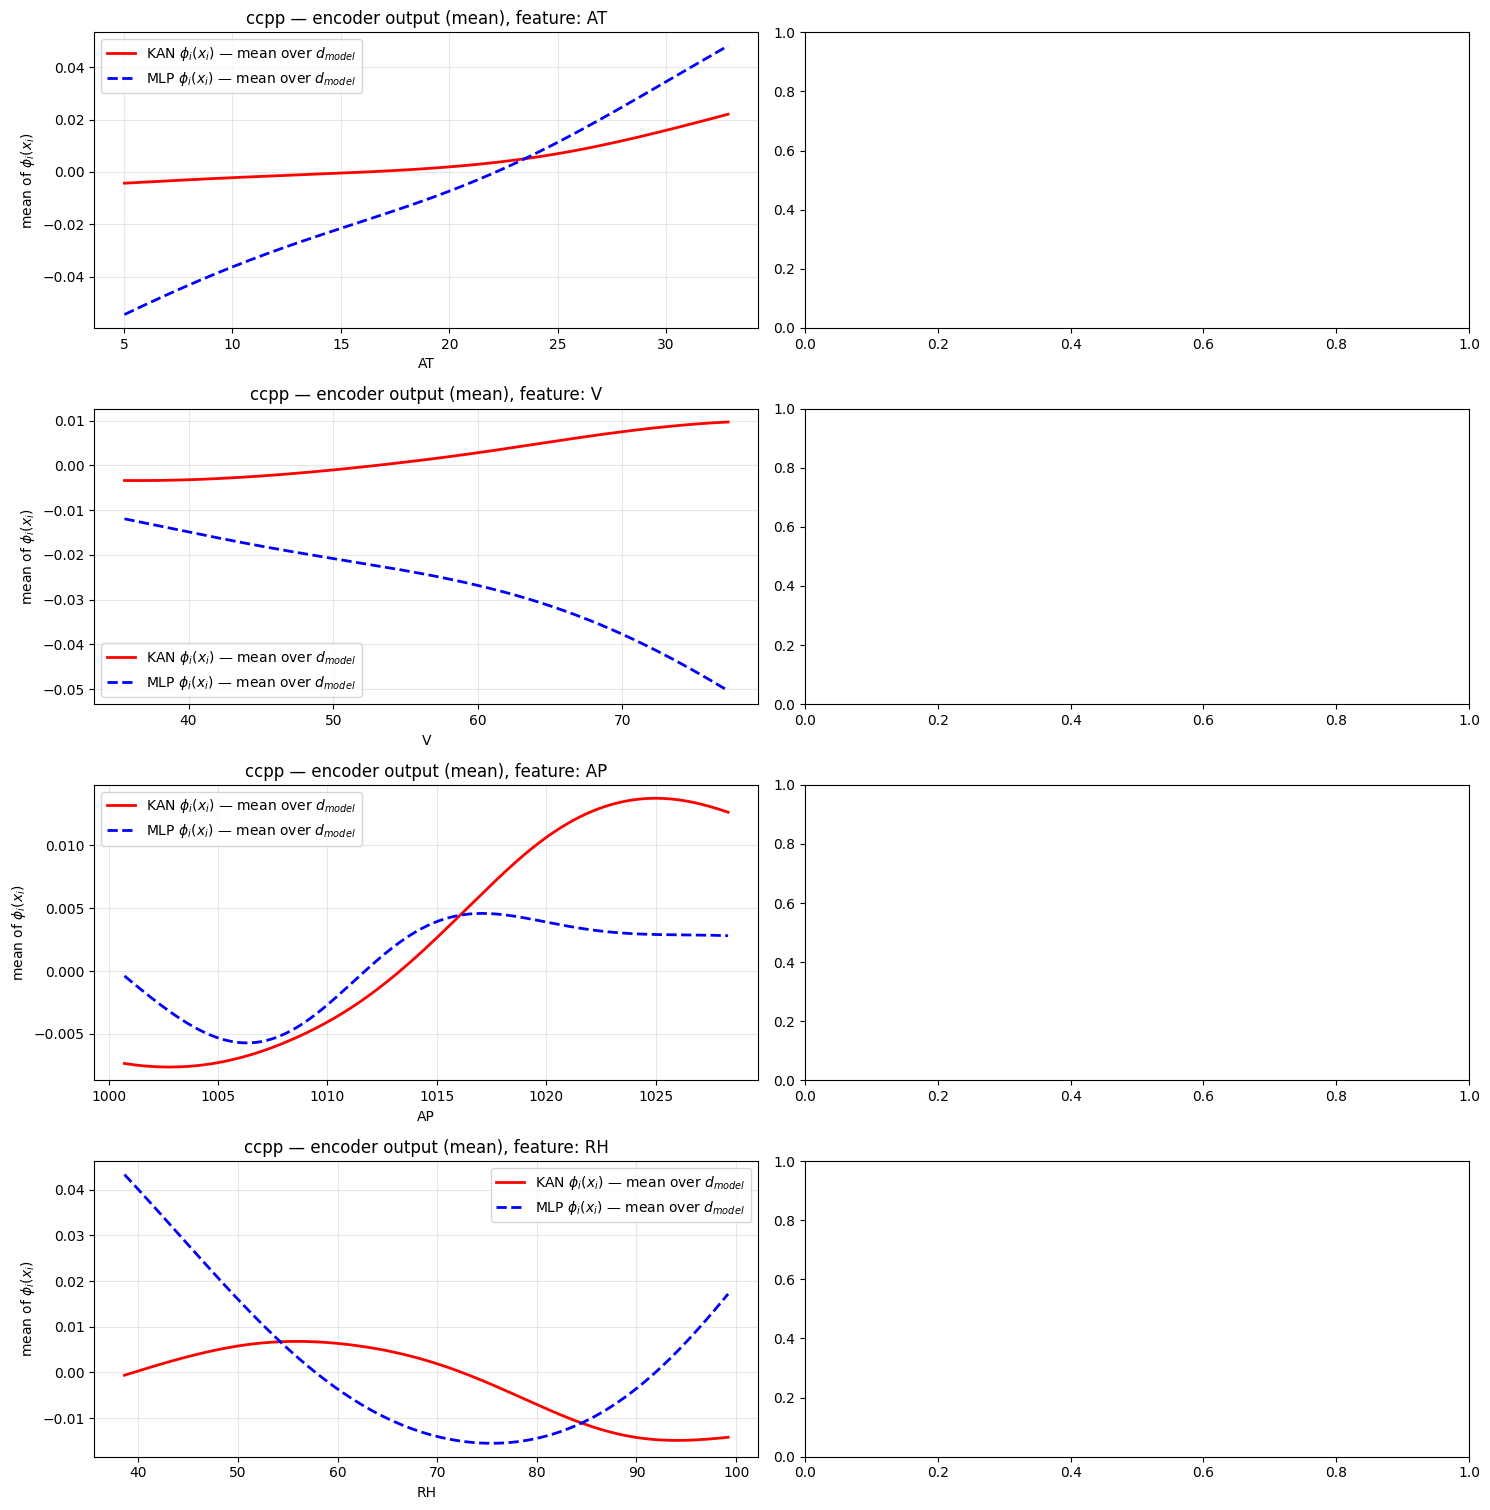

In [37]:
# Выбираем любой датасет из успешных
DATASET_NAME = "ccpp"   # или "ccpp", "concrete", "abalone"

if DATASET_NAME in real_artifacts:
    artifact = real_artifacts[DATASET_NAME]
    feature_names = artifact["feature_names"]
    print(f"{DATASET_NAME}: {len(feature_names)} features")
    print(f"feature_names = {feature_names}")

    # --- Скалярные кривые + PCA-траектории ---
    plot_tabkanet_encoder_outputs(
        artifact, DATASET_NAME,
        feature_indices=list(range(min(4, len(feature_names)))),
        n_points=200,
    )
else:
    print(f"{DATASET_NAME} не найден. Доступные: {list(real_artifacts.keys())}")